# Fare Amount Dataset 

## 1. Data Preprocessing

#### Preparations

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, stats , boxcox, skew
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

dataset= pd.read_csv(r"e:\Courses\Cellula\Datasets\final_internship_data.csv")

#### Data Understanding

In [2]:
dataset  # show dataset

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,er7Luy6J,Morgan Smith,Gabriel Coleman,Bad,rainy,Dense Traffic,2015-05-07 18:45:12.0000004,7.0,2015-05-07 18:45:12,-1.291173,...,5,3,2015,42.565403,36.580043,17.157511,20.401068,12.280187,1.404709,-2.275706
499996,FWDZu9NA,Dillon Jackson,Larry Richards,Very Good,rainy,Flow Traffic,2010-09-13 12:11:34.0000004,13.7,2010-09-13 12:11:34,-1.291595,...,9,0,2010,41.814877,27.833416,26.463167,8.596656,0.994796,0.994184,2.556931
499997,QZIMcpLZ,Michael Rodriguez,Lonnie Santana,Bad,rainy,Flow Traffic,2014-08-25 00:22:20.0000001,25.0,2014-08-25 00:22:20,-1.291262,...,8,0,2014,31.780108,38.960930,19.708214,19.066488,11.663395,7.859324,-1.926251
499998,AD72Uwmn,Deborah Soto,Emily Rivera,Good,stormy,Congested Traffic,2015-01-12 12:17:32.0000001,6.5,2015-01-12 12:17:32,-1.291101,...,1,0,2015,42.292914,36.382813,17.227166,20.006433,11.819775,0.994470,-0.384817


In [3]:
dataset.shape

(500000, 26)

In [4]:
dataset.info() # columns datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [5]:
# Separate categorical columns
categorical_cols = dataset.select_dtypes(include=["object", "category"]).columns.tolist()

# Drop unwanted columns
categorical_cols = [col for col in categorical_cols if col not in ["User ID", "User Name",'Driver Name','pickup_datetime','key']]

for col in categorical_cols:
    print(f"Column: {col}")
    print(dataset[col].unique())  
    print("-" * 50)  


Column: Car Condition
['Very Good' 'Excellent' 'Bad' 'Good']
--------------------------------------------------
Column: Weather
['windy' 'cloudy' 'stormy' 'sunny' 'rainy']
--------------------------------------------------
Column: Traffic Condition
['Congested Traffic' 'Flow Traffic' 'Dense Traffic']
--------------------------------------------------


### Explanation of Each Column in the Dataset:  

User_ID:  A unique number for each user.  
User Name:  The user's name.  
Driver Name:  The driver's name.  
Car Condition: The condition of the car (good or bad).  
Weather:  Weather conditions (winter, windy, sunny).  
Traffic Conditions: Traffic status (congested or normal).  
Key:  A unique number for each trip.  
Fare Amount: The trip fare.  
Pickup Datetime:  The time when the passenger requested Uber.  
Pickup Longitude & Latitude: The coordinates of the starting location (passenger's location).  
Drop-off Longitude & Latitude:  The coordinates of the drop-off location (where the passenger arrived).  
Passenger Count:  The number of passengers in the same car.  
Hour, Day, Month, Week: Repeated time details of when the passenger requested Uber.  
JFK, EWR, LGA Distance:  These are airport names; the distance between them and the pickup point.  
SOL Distance:The distance to the Statue of Liberty.  
Distance: The total trip distance.  
Bearing:  The trip direction from start to end, measured in angles. 

#### Data Checking & Modifications

In [6]:
dataset.isnull().sum()  # Check missing values = Null

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

In [7]:
num_cols_nulls = ['dropoff_longitude', 'dropoff_latitude', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance', 'bearing']
dataset[num_cols_nulls] = dataset[num_cols_nulls].fillna(dataset[num_cols_nulls].median())


In [8]:
dataset.isnull().mean() * 100   # % of missing data

# Handling Missing Values: (If presented)
# If categorical → Fill missing values with the mode (most frequent value).
# If numerical   → Fill missing values with the median to prevent skewing the data.

User ID              0.0
User Name            0.0
Driver Name          0.0
Car Condition        0.0
Weather              0.0
Traffic Condition    0.0
key                  0.0
fare_amount          0.0
pickup_datetime      0.0
pickup_longitude     0.0
pickup_latitude      0.0
dropoff_longitude    0.0
dropoff_latitude     0.0
passenger_count      0.0
hour                 0.0
day                  0.0
month                0.0
weekday              0.0
year                 0.0
jfk_dist             0.0
ewr_dist             0.0
lga_dist             0.0
sol_dist             0.0
nyc_dist             0.0
distance             0.0
bearing              0.0
dtype: float64

In [9]:
sum(dataset.duplicated())       # check count of duplicated rows
# dataset[dataset.duplicated()] → Display duplicated rows (if Presented)

0

In [10]:
(dataset.select_dtypes(include=['number']) < 0).sum()  # show how many negative values exist in numerical features


fare_amount              21
pickup_longitude     490303
pickup_latitude         264
dropoff_longitude    490279
dropoff_latitude        267
passenger_count           0
hour                      0
day                       0
month                     0
weekday                   0
year                      0
jfk_dist                  0
ewr_dist                  0
lga_dist                  0
sol_dist                  0
nyc_dist                  0
distance                  0
bearing              254228
dtype: int64

In [11]:
dataset = dataset[dataset['fare_amount'] >= 0]
dataset = dataset[(dataset['pickup_longitude'] >= -180) & (dataset['pickup_longitude'] <= 180)]
dataset = dataset[(dataset['pickup_latitude'] >= -90) & (dataset['pickup_latitude'] <= 90)]
dataset = dataset[(dataset['dropoff_longitude'] >= -180) & (dataset['dropoff_longitude'] <= 180)]
dataset = dataset[(dataset['dropoff_latitude'] >= -90) & (dataset['dropoff_latitude'] <= 90)]
dataset['bearing'] = dataset['bearing'] % 360  # Converts negatives into valid range


#### Overall Describtion

In [12]:
dataset.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000,499979.000000
mean,11.359104,-1.265711,0.696740,-1.265757,0.696676,1.683423,13.510987,15.684109,6.268761,3.041976,2011.739063,385.273223,380.497209,363.837493,363.667608,355.984992,19.452053,183.341079
std,9.915980,0.206945,0.140912,0.205898,0.128996,1.307388,6.511485,8.681084,3.437822,1.949236,1.860842,2419.097224,2428.814299,2425.085496,2428.358254,2428.740401,367.102729,178.455398
min,0.000000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,0.000000
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341570,32.173712,17.100805,14.886998,7.147468,1.214646,2.262824
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116987,356.909513
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785614,38.304279,22.214784,22.417547,14.448546,3.890101,359.189654
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,360.000000


In [13]:
# Clarify numerical & Categorical columns
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
cat_cols = dataset.select_dtypes(include=['object']).columns.tolist()

excluded_cols = ["User ID", "User Name",'Driver Name','pickup_datetime','key']             # Drop excluded columns 
cat_cols = [col for col in cat_cols if col not in excluded_cols]


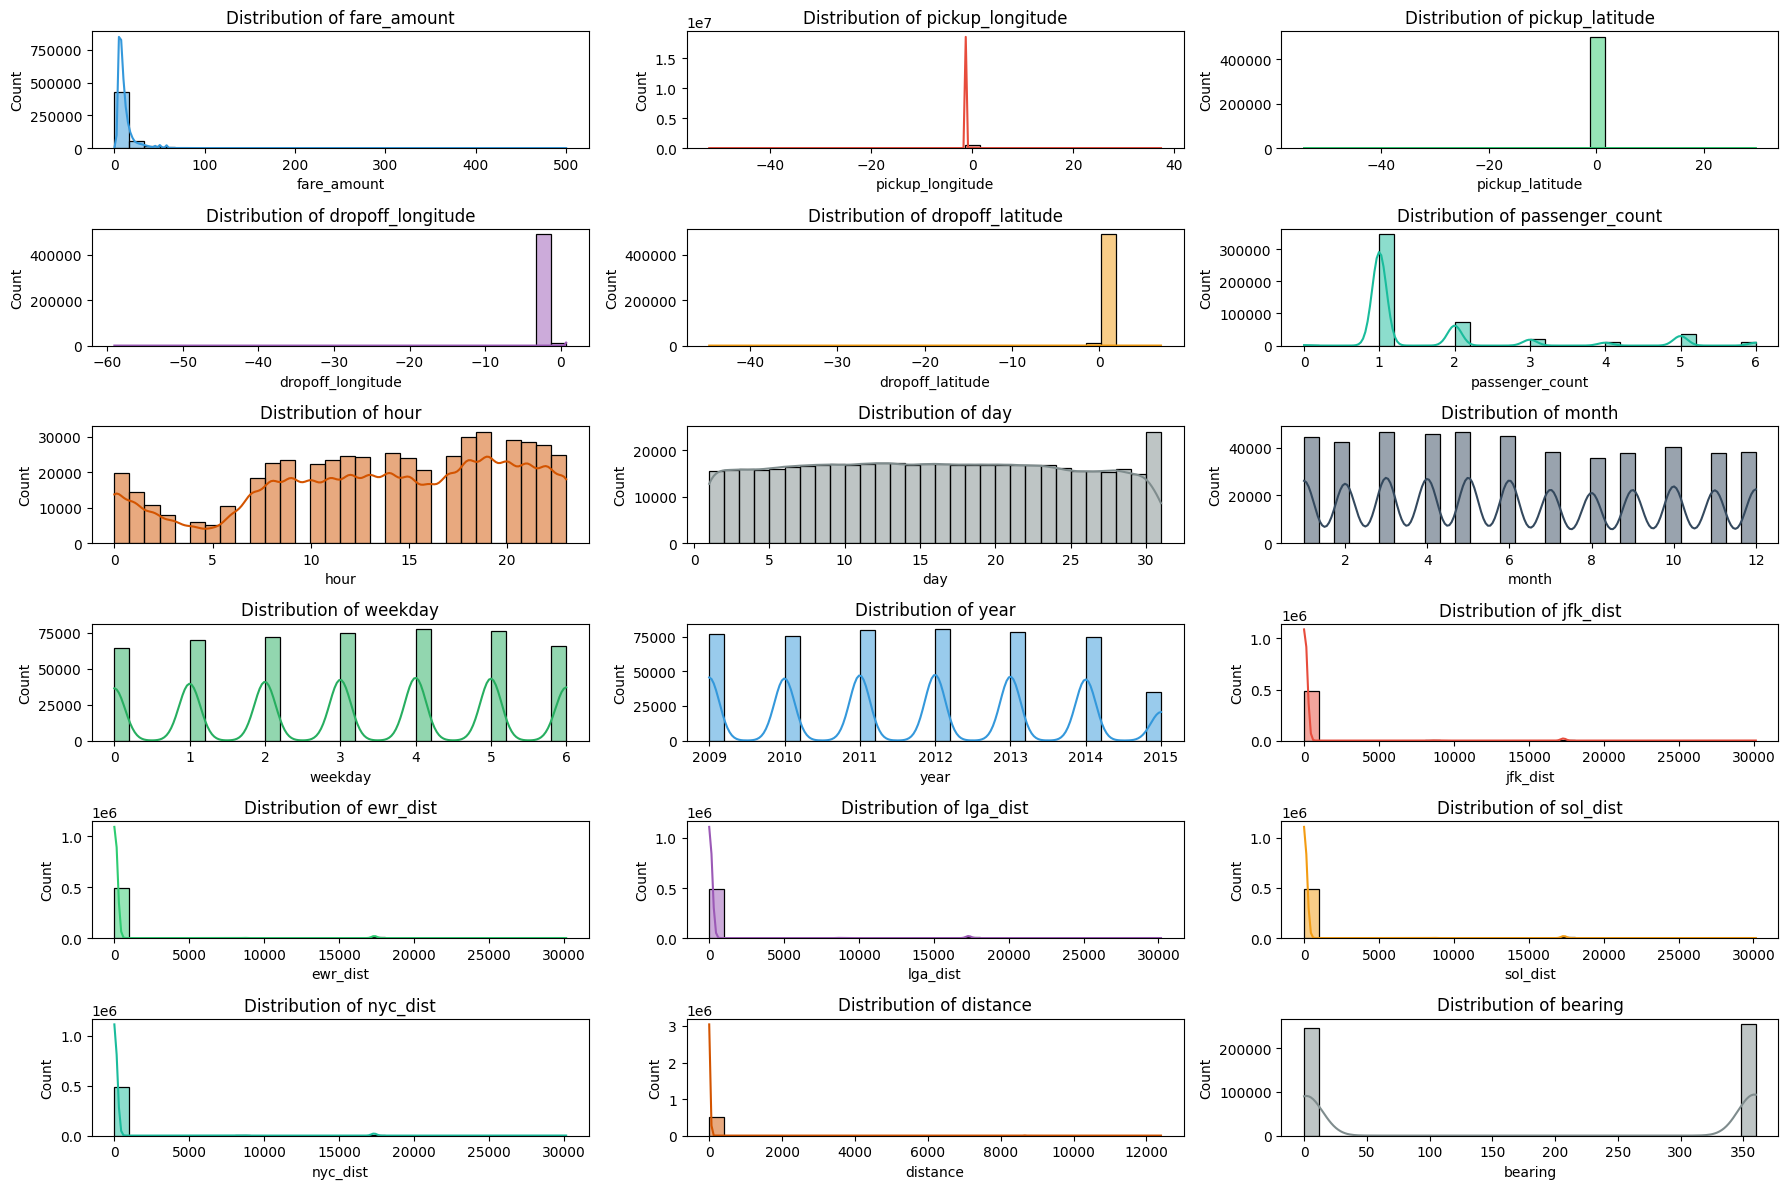

In [14]:
# Visualize Numerical Features
colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c", "#d35400", "#7f8c8d", "#34495e", "#27ae60"]
num_features = len(num_cols)
rows = (num_features // 3) + (num_features % 3 > 0)  # Adjust rows dynamically
fig, axes = plt.subplots(rows, 3, figsize=(18, 12))
axes = axes.flatten()  

for i, col in enumerate(num_cols):
    sns.histplot(dataset[col], bins=30, kde=True, ax=axes[i], color=colors[i % len(colors)])  
    axes[i].set_title(f"Distribution of {col}")
for j in range(i + 1, len(axes)): # Hide unused subplots if num_features is not a multiple of 3
    fig.delaxes(axes[j])  

plt.tight_layout()
plt.show()



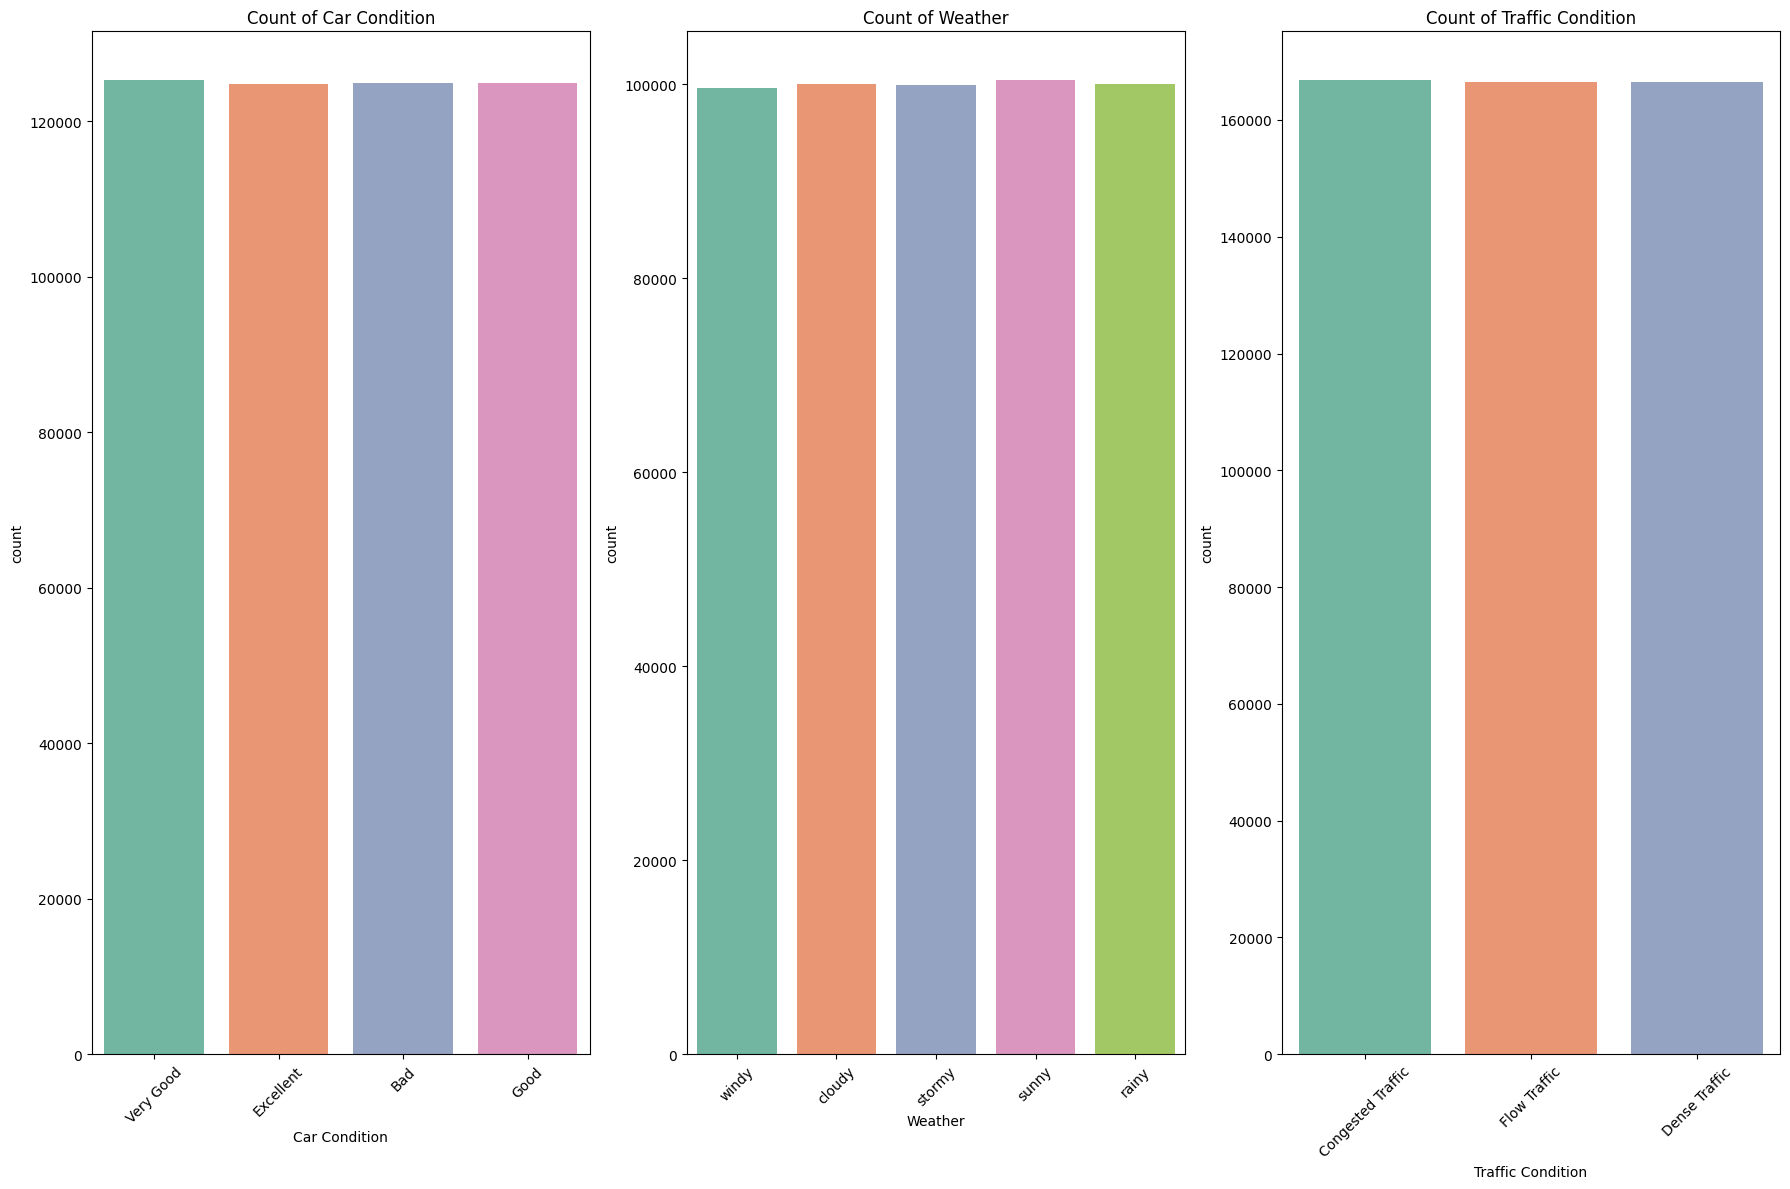

In [15]:
# Visualize Categorical Features
cat_features = len(cat_cols)
rows = (cat_features // 3) + (cat_features % 3 > 0)  # Adjust rows dynamically
fig, axes = plt.subplots(rows, 3, figsize=(18, 12))
axes = axes.flatten()  

for i, col in enumerate(cat_cols):
    palette = sns.color_palette("Set2", n_colors=len(dataset[col].unique()))  
    sns.countplot(x=dataset[col], ax=axes[i], hue=dataset[col], palette=palette, legend=False)  
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45) 

for j in range(i + 1, len(axes)):   # Hide unused subplots if cat_features is not a multiple of 3
    fig.delaxes(axes[j])  

plt.tight_layout()
plt.show()




## 2. Handling Outliers

### A) Detecting Phase

     · Removing outliers should not be done casually and arbitrary.
     . This can lead to overconfidence in results, because we removed the relevant variability in the data.
     · Removing outliers, or minimizing their effect through Winsorization or robust techniques like using medians instead of means, should always take into account the goals of the analysis.
     · Are the outliers relevant to the question we want to answer?
     · If they are, don't just remove them! That would be silly and will give you misleading results



In [16]:
def print_outliers_iqr(data_set, factor=1.5):  # print outliers using the IQR method and prints row count before and after removal."""
    
    
    original_shape = data_set.shape[0]  # Store original shape before removing outliers
    cleaned_data = data_set.copy()

    for col in num_cols:
        Q1 = cleaned_data[col].quantile(0.25)
        Q3 = cleaned_data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        cleaned_data = cleaned_data[(cleaned_data[col] >= lower_bound) & (cleaned_data[col] <= upper_bound)]  # Remove outliers for each column

    new_shape = cleaned_data.shape[0]

    
    print(f"🔹 Rows before removing outliers: {original_shape}")
    print(f"🔹 Rows after removing outliers: {new_shape}")
    print(f"🔹 Rows removed (outliers detected): {original_shape - new_shape} \n which is {100-int((new_shape/original_shape)*100)} % from dataset")

print_outliers_iqr(dataset)

# Try to separate to get more efficiency in detection


🔹 Rows before removing outliers: 499979
🔹 Rows after removing outliers: 341505
🔹 Rows removed (outliers detected): 158474 
 which is 32 % from dataset


In [17]:
def classify_features_by_skewness(df, threshold=0.5):
    normal_features = []
    skewed_features = []
    for column in df.select_dtypes(include=['number']).columns:  # Loop through numeric features
        skewness = df[column].skew()
        if abs(skewness) < threshold:
            normal_features.append(column)
        else:
            skewed_features.append(column)
    
    print(f"✅ Normal Features: {normal_features}")
    print(f"🚨 Skewed Features: {skewed_features}")
    
    return normal_features, skewed_features

normal_features, skewed_features = classify_features_by_skewness(dataset)    # Seperate Normal & Skewed features to apply Z-Score & IQR


✅ Normal Features: ['hour', 'day', 'month', 'weekday', 'year', 'bearing']
🚨 Skewed Features: ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance']


In [18]:
def count_total_outliers(data_set, factor=1.5): # count outliers for each skewed features using the IQR method
    total_outliers = 0

    for col in skewed_features:
        Q1 = data_set[col].quantile(0.25)
        Q3 = data_set[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        outliers = data_set[(data_set[col] < lower_bound) | (data_set[col] > upper_bound)]
        num_outliers = outliers.shape[0]

        total_outliers += num_outliers
        print(f"Outliers in Column ({col}) = {num_outliers}")

    print("=" * 40)
    print(f"🔹 Total Outliers in Dataset: {total_outliers}")

count_total_outliers(dataset)


Outliers in Column (fare_amount) = 43322
Outliers in Column (pickup_longitude) = 33961
Outliers in Column (pickup_latitude) = 23701
Outliers in Column (dropoff_longitude) = 35801
Outliers in Column (dropoff_latitude) = 30748
Outliers in Column (passenger_count) = 56523
Outliers in Column (jfk_dist) = 59285
Outliers in Column (ewr_dist) = 28377
Outliers in Column (lga_dist) = 22536
Outliers in Column (sol_dist) = 18608
Outliers in Column (nyc_dist) = 21940
Outliers in Column (distance) = 41924
🔹 Total Outliers in Dataset: 416726


In [19]:
def print_outliers_iqr(data_set, factor=1.5): #  count total outliers using the IQR method for all skewed features
    original_shape = data_set.shape[0]
    cleaned_data = data_set.copy()

    for col in skewed_features:
        Q1 = cleaned_data[col].quantile(0.25)
        Q3 = cleaned_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Remove outliers for this column
        cleaned_data = cleaned_data[(cleaned_data[col] >= lower_bound) & (cleaned_data[col] <= upper_bound)]

    # Store new shape after outlier removal
    new_shape = cleaned_data.shape[0]

    # Print before & after outlier removal
    print(f"🔹 Rows before removing outliers: {original_shape}")
    print(f"🔹 Rows after removing outliers: {new_shape}")
    print(f"🔹 Rows removed (outliers detected): {original_shape - new_shape} \n which is {100-int((new_shape/original_shape)*100)} % from dataset")


# Call the function
print_outliers_iqr(dataset)

# ✅ Best For:
# Skewed distributions (e.g., prices, salaries, time intervals).
# Non-Gaussian (non-normal) data.

# Comparing btw prev code O/P (10041) & this code O/P (7360) means that Some rows are outliers in multiple columns and are counted more than once


🔹 Rows before removing outliers: 499979
🔹 Rows after removing outliers: 341505
🔹 Rows removed (outliers detected): 158474 
 which is 32 % from dataset


In [20]:
def print_outliers_zscore(data, threshold=3):        #  count total outliers using the Zscore method for all normal features
    z_scores = np.abs(zscore(data[normal_features]))
    filtered_data = data[(z_scores < threshold).all(axis=1)]
    
    print(f"🔹 Rows before removing outliers: {data.shape[0]}")
    print(f"🔹 Rows after removing outliers: {filtered_data.shape[0]}")
    print(f"🔹 Rows removed: {data.shape[0] - filtered_data.shape[0]} \n which is {100-int((filtered_data.shape[0]/data.shape[0])*100)} % from dataset")


print_outliers_zscore(dataset)

# ✅ Best For:
# Normally distributed data.
# When the dataset size is large (outliers don’t heavily impact the mean).


🔹 Rows before removing outliers: 499979
🔹 Rows after removing outliers: 499979
🔹 Rows removed: 0 
 which is 0 % from dataset


### B) Visulaizing before Treatment

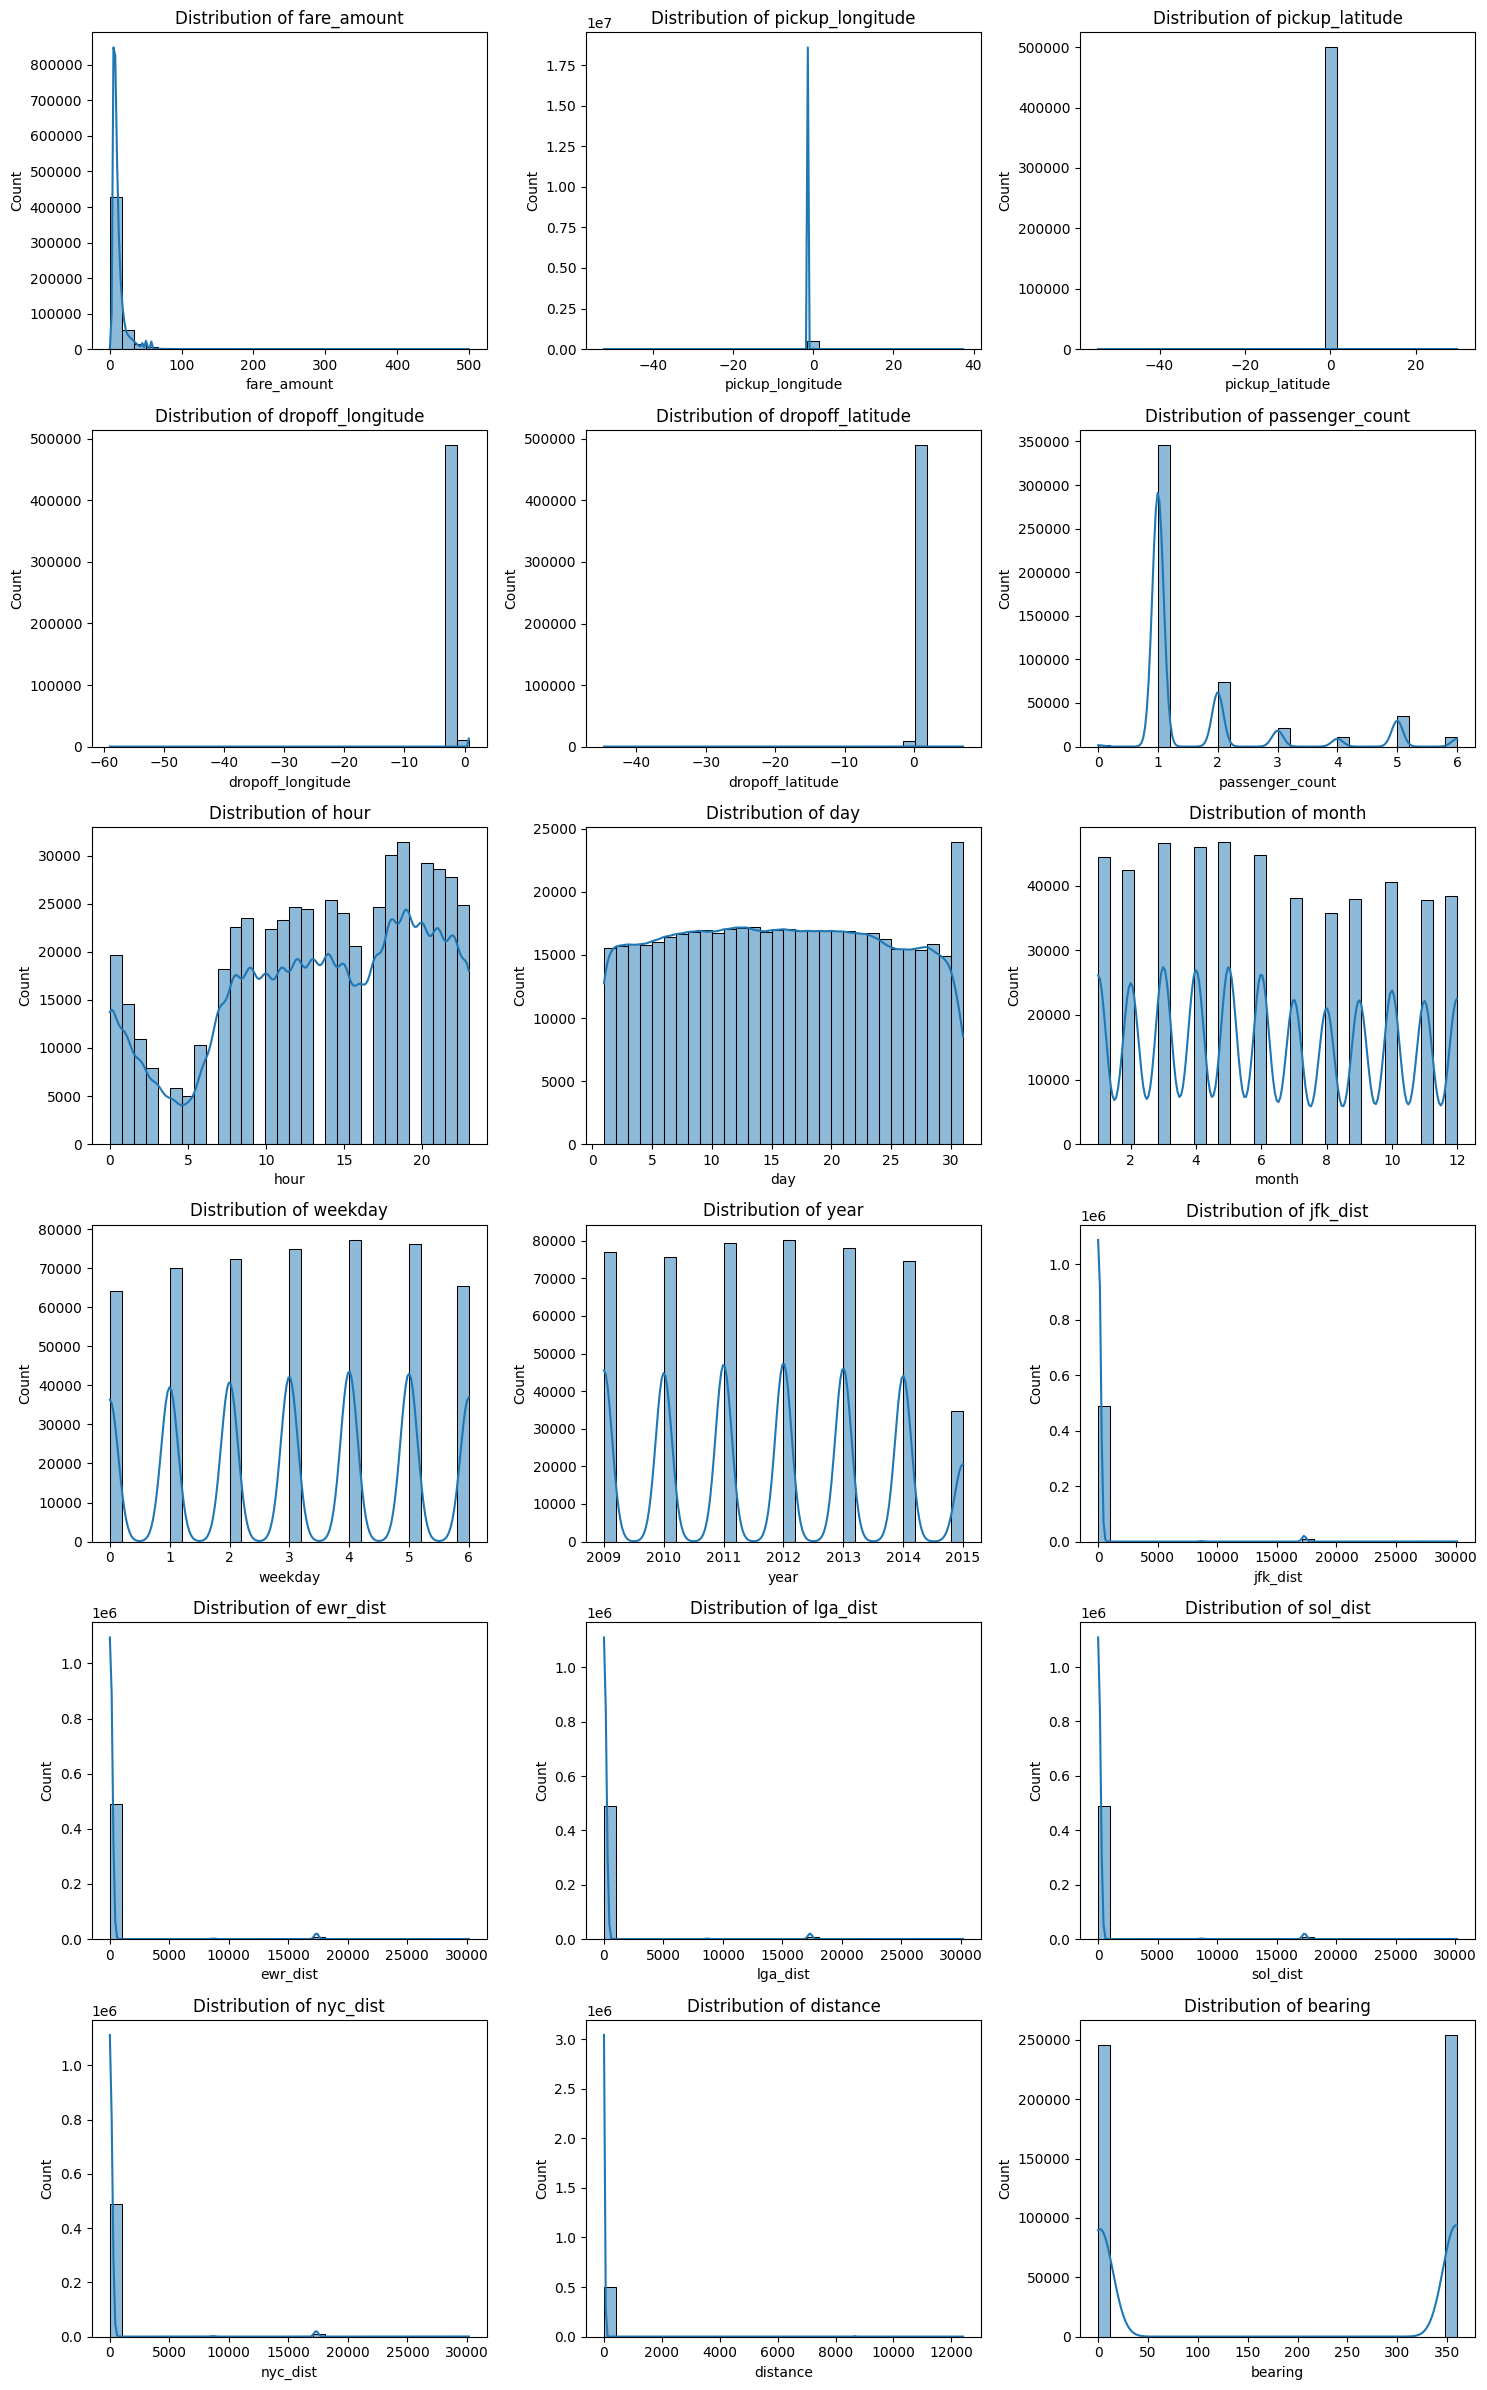

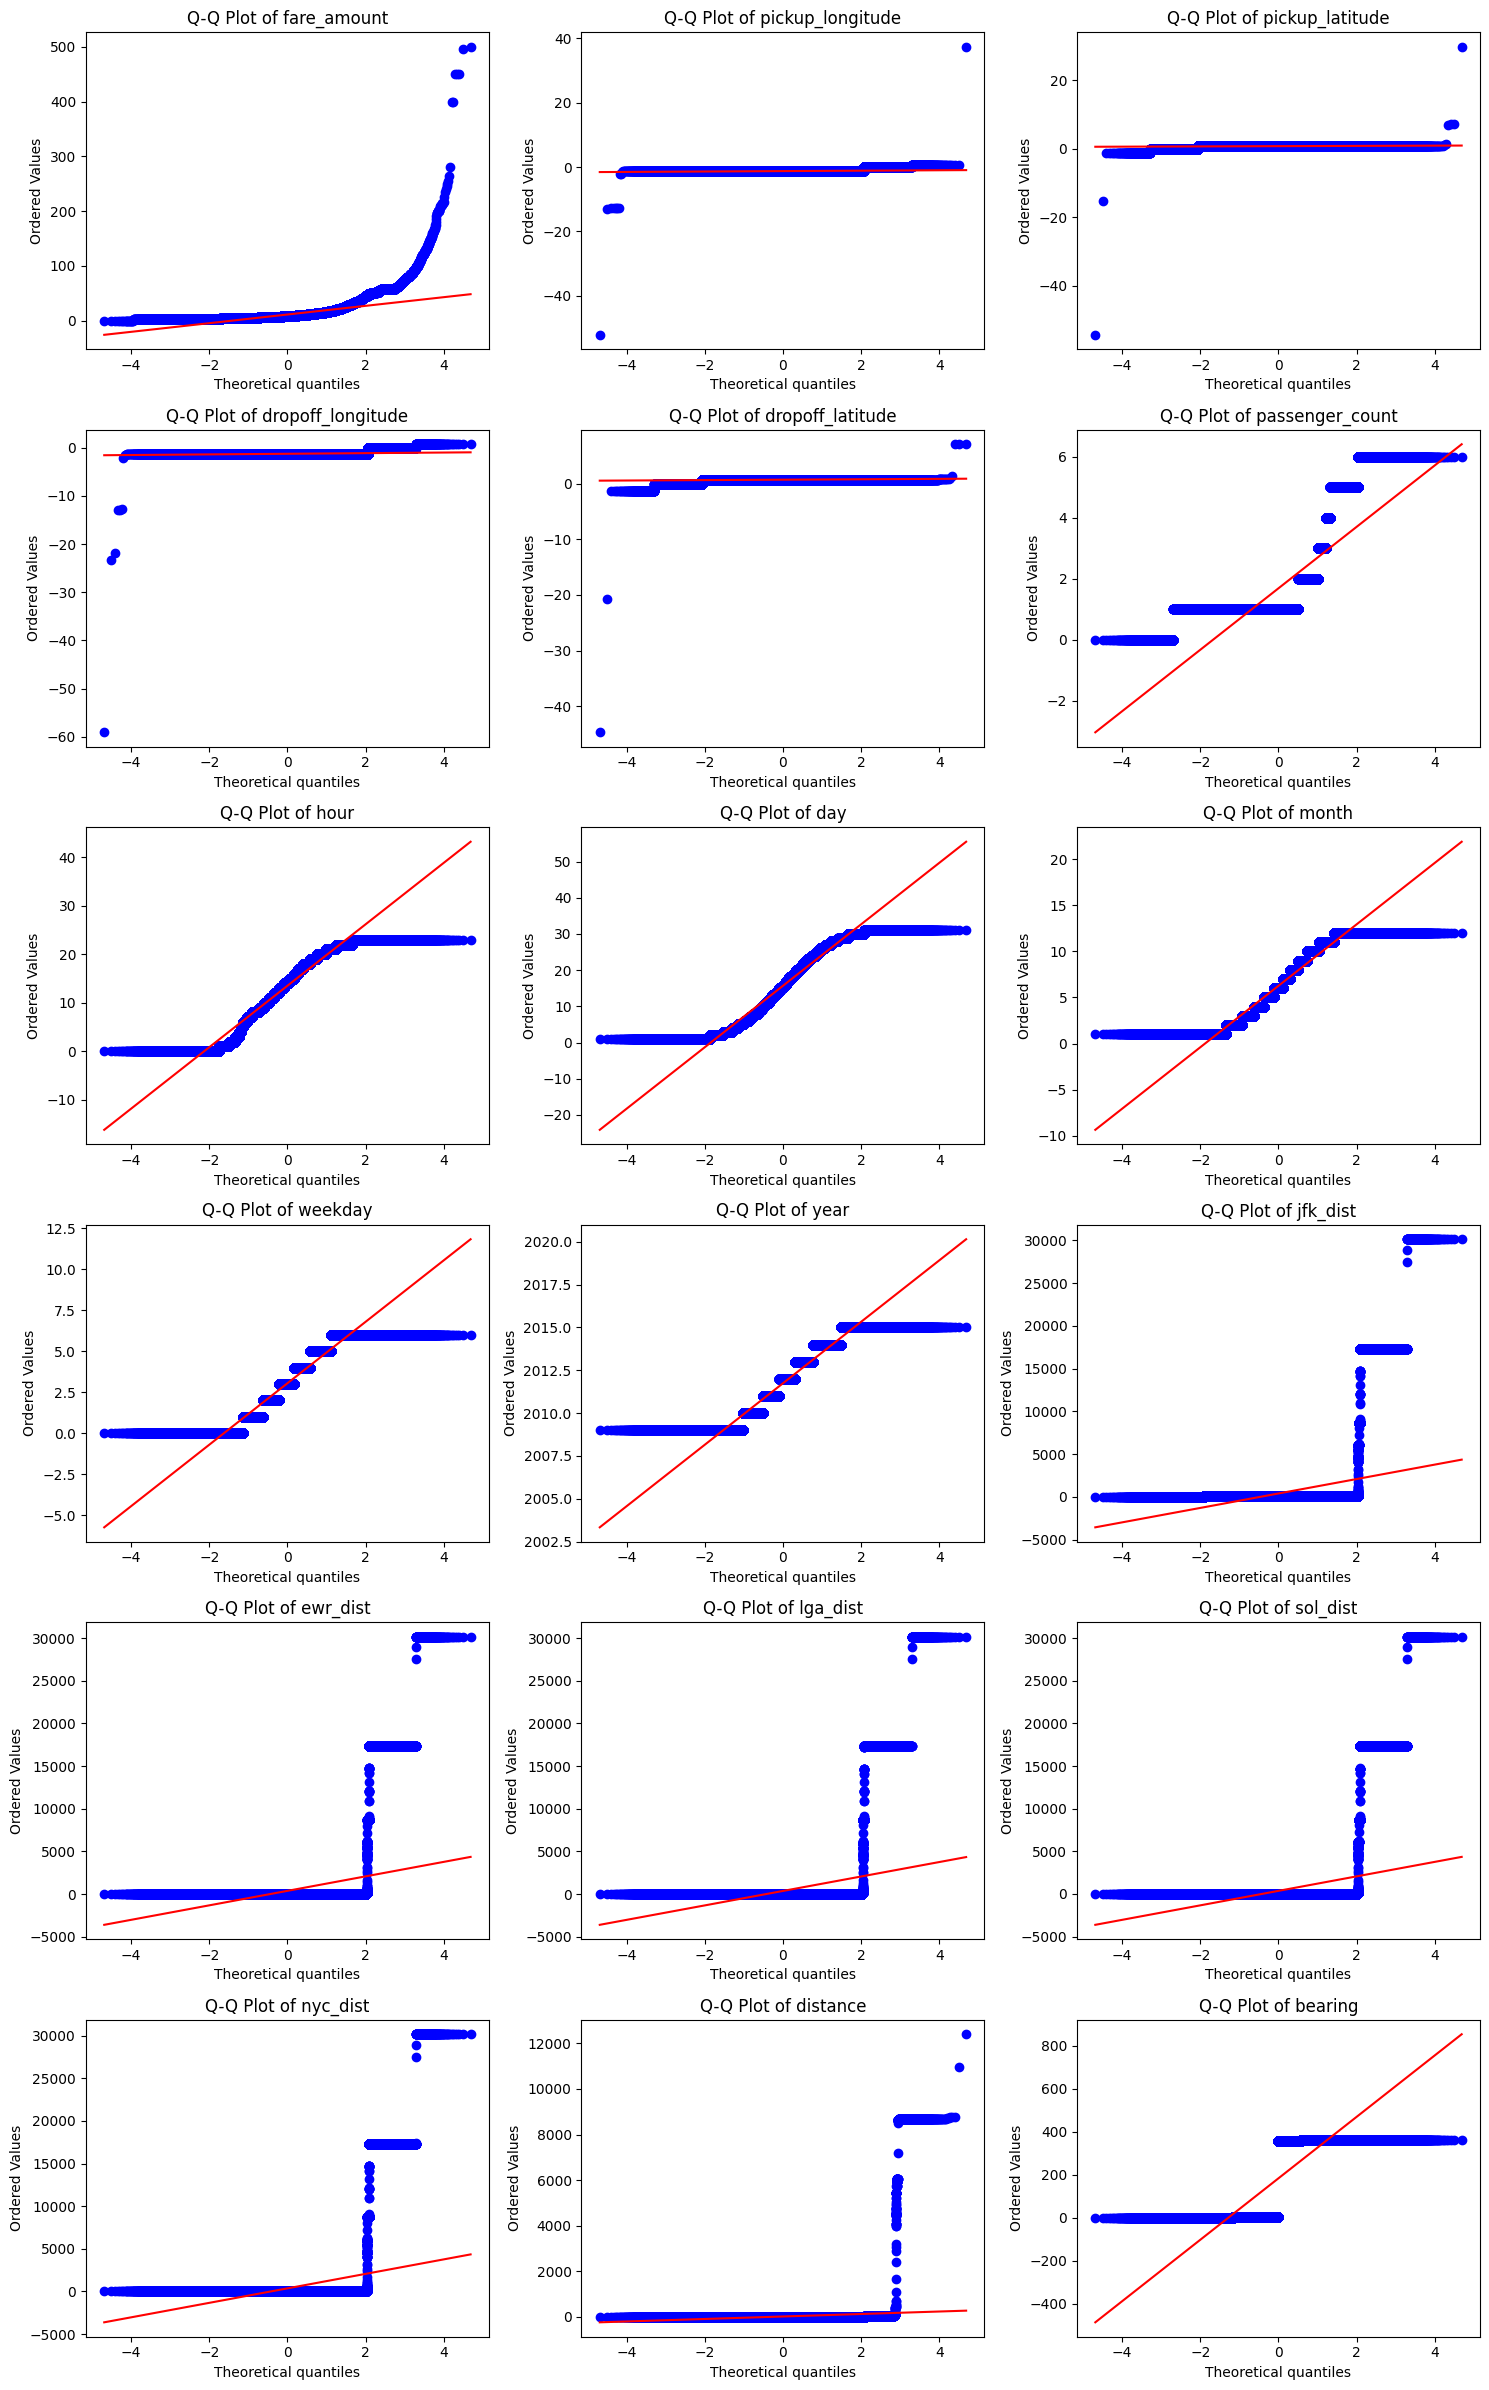

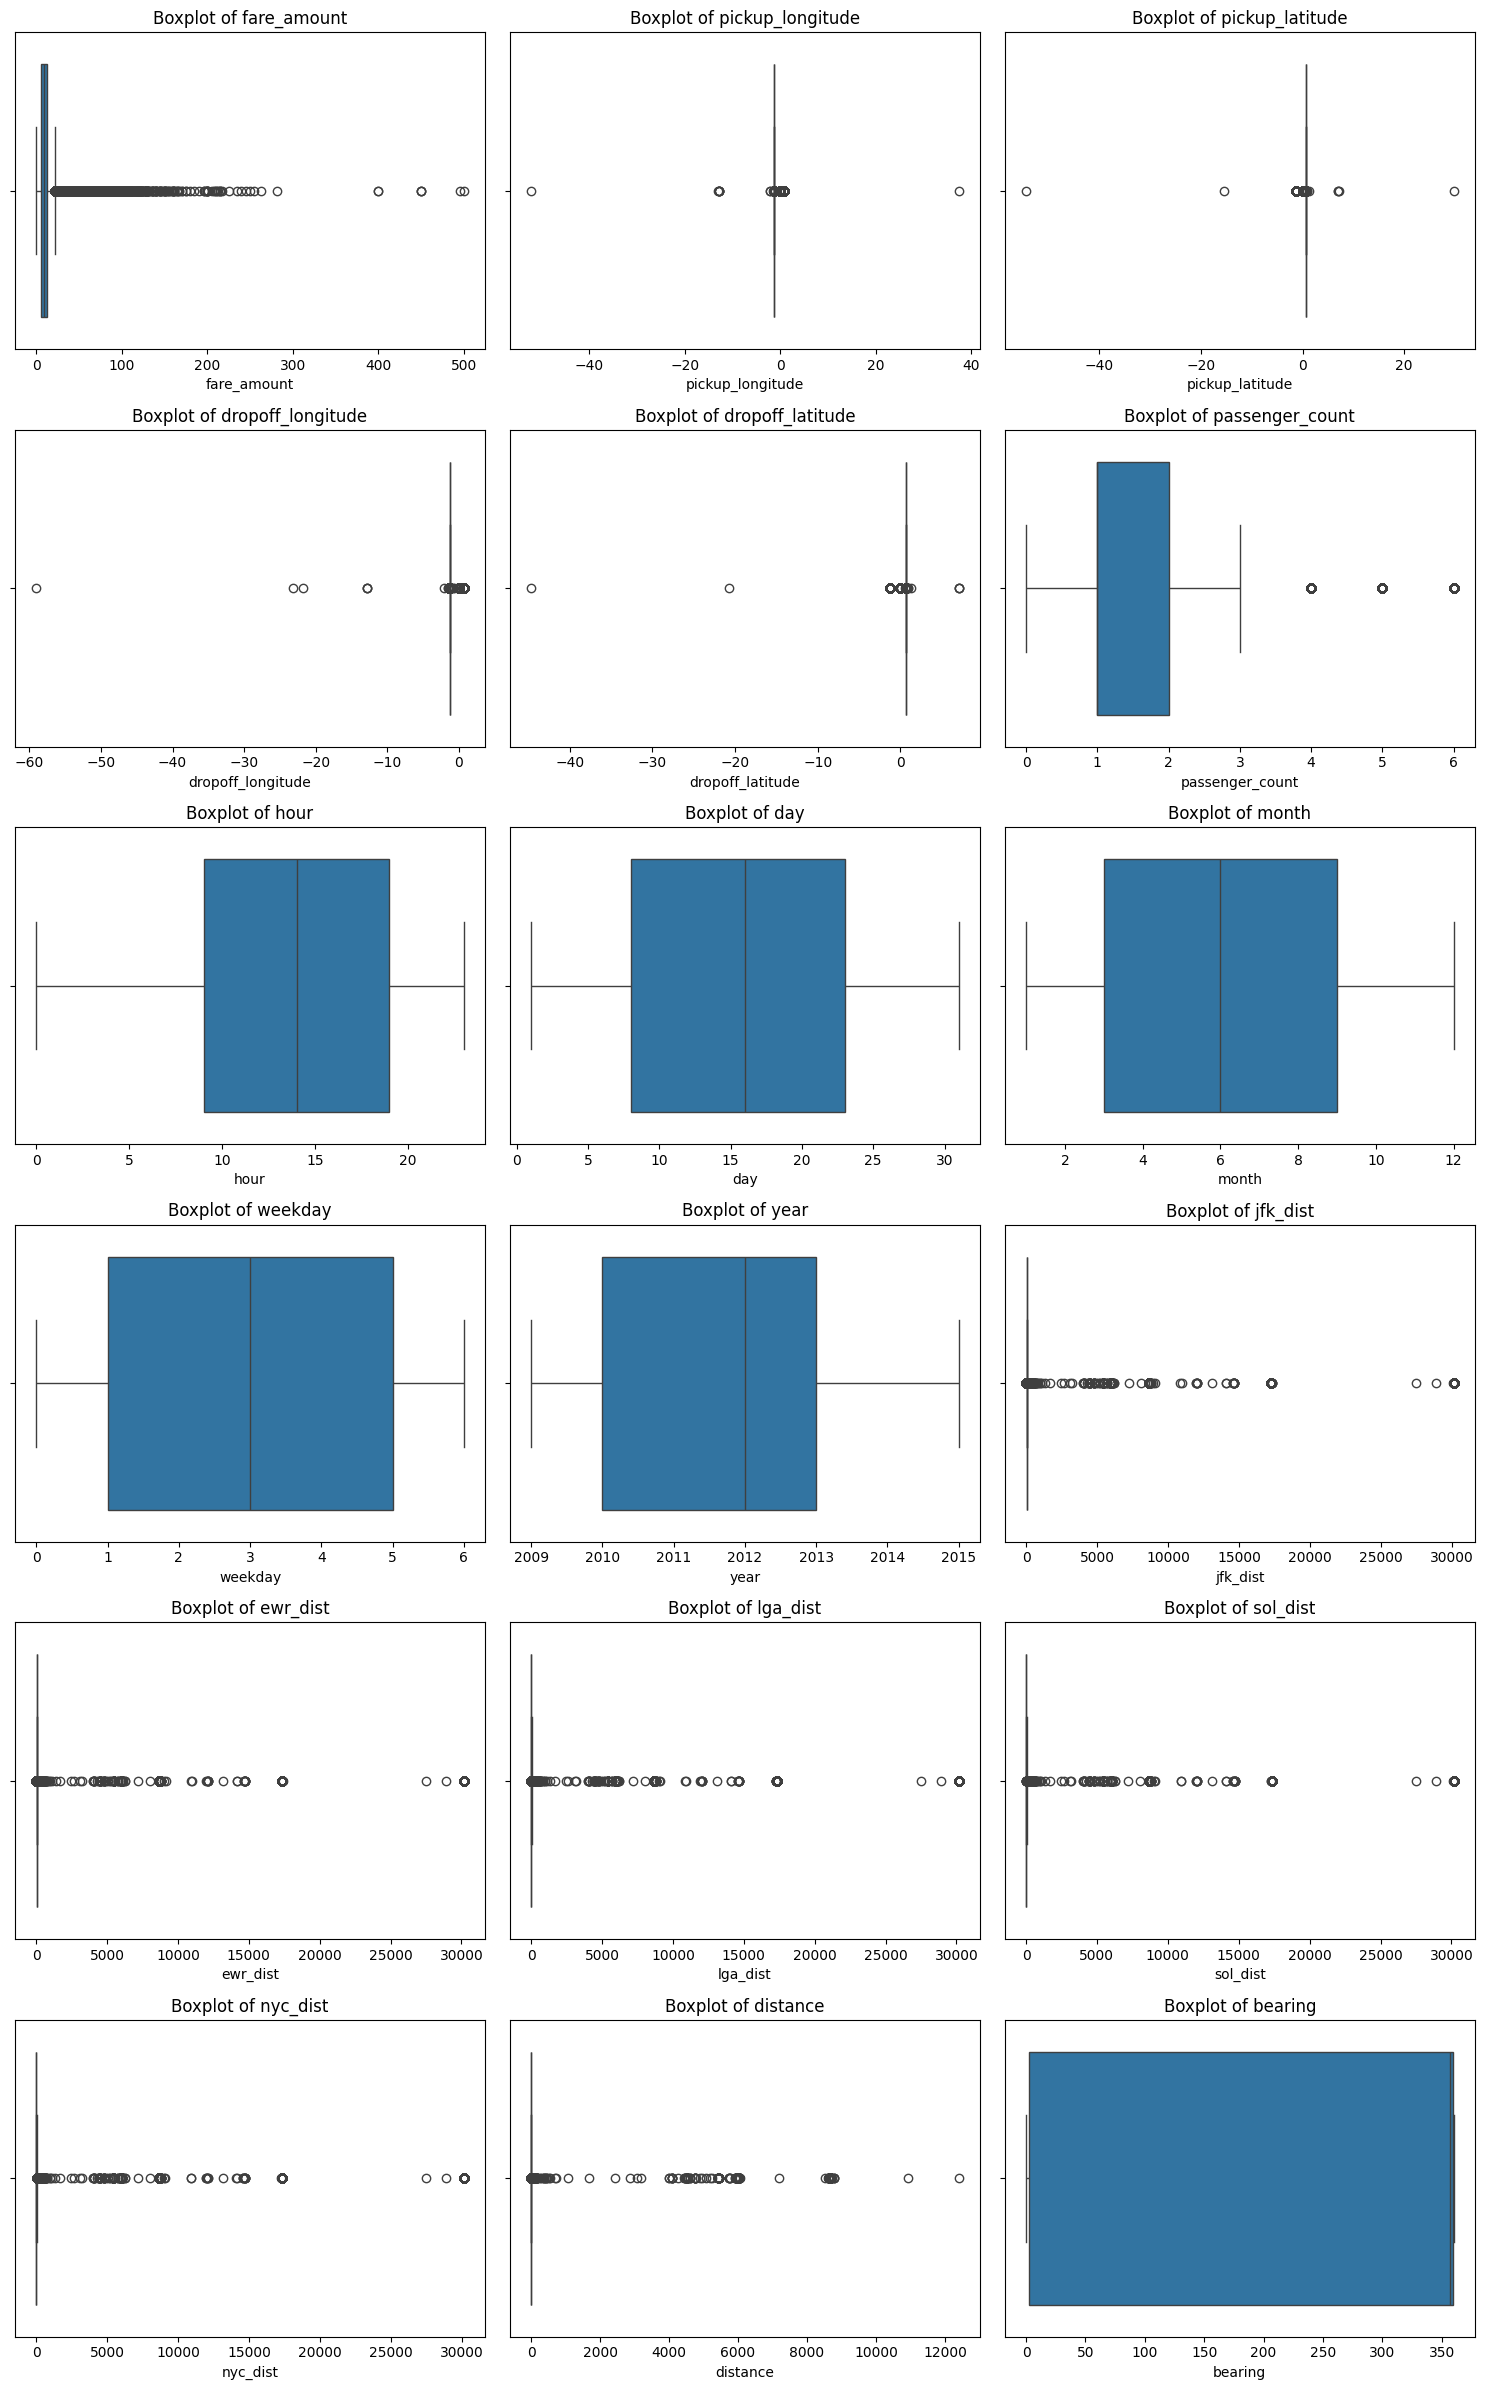

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

num_cols = dataset.select_dtypes(include=['number']).columns  # Get numerical columns
n_cols = 3  # Number of columns in the grid
n_rows = int(np.ceil(len(num_cols) / n_cols))  # Calculate required rows dynamically

plt.figure(figsize=(15, n_rows * 4))

# Histograms
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(dataset[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Q-Q Plots
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    stats.probplot(dataset[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')

plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


### C) Treatment phase

In [22]:
dataset_treated= dataset.copy()

In [23]:
def detect_skewness_and_suggest_transformation(data, threshold=0.5):    # Type of skewness to be treated
    skew_info = {}

    # Loop through numerical skewed features
    for col in skewed_features:
        skewness = data[col].skew()

        if abs(skewness) < threshold:
            suggestion = "No transformation needed (approximately normal)"
        elif skewness > 0:
            suggestion = "Right-skewed → Try Log, Square Root, or Box-Cox"
        else:
            suggestion = "Left-skewed → Try Exponential or Box-Cox transformation"

        skew_info[col] = {"Skewness": round(skewness, 3), "Suggestion": suggestion}

    skew_df = pd.DataFrame.from_dict(skew_info, orient='index')  # Convert results to DataFrame for better readability
    return skew_df

skewness_results = detect_skewness_and_suggest_transformation(dataset_treated)
print(skewness_results)



                   Skewness                                         Suggestion
fare_amount           4.900    Right-skewed → Try Log, Square Root, or Box-Cox
pickup_longitude    -14.006  Left-skewed → Try Exponential or Box-Cox trans...
pickup_latitude    -108.092  Left-skewed → Try Exponential or Box-Cox trans...
dropoff_longitude   -44.824  Left-skewed → Try Exponential or Box-Cox trans...
dropoff_latitude   -100.314  Left-skewed → Try Exponential or Box-Cox trans...
passenger_count       1.974    Right-skewed → Try Log, Square Root, or Box-Cox
jfk_dist              7.168    Right-skewed → Try Log, Square Root, or Box-Cox
ewr_dist              7.165    Right-skewed → Try Log, Square Root, or Box-Cox
lga_dist              7.167    Right-skewed → Try Log, Square Root, or Box-Cox
sol_dist              7.165    Right-skewed → Try Log, Square Root, or Box-Cox
nyc_dist              7.165    Right-skewed → Try Log, Square Root, or Box-Cox
distance             23.000    Right-skewed → Try Lo

In [24]:
import numpy as np
import pandas as pd
import scipy.stats as stats

def log_sqrt_transform(dataset, column):
    """Apply log transformation first, then square root for further normalization."""
    transformed = np.log1p(dataset[column])  # Log transformation (log(1 + x) avoids log(0))
    transformed = np.sqrt(transformed)       # Additional smoothing
    return transformed  # Return transformed column

# Right-skewed features that need Log/Square Root/Box-Cox
right_skewed_features = [
    "fare_amount", "passenger_count", "jfk_dist", "ewr_dist", "lga_dist",
    "sol_dist", "nyc_dist", "distance"
]

# Left-skewed features that may need Exponential or Box-Cox
left_skewed_features = [
    "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"
]

# Apply transformations for right-skewed features
for col in right_skewed_features:
    dataset[col] = log_sqrt_transform(dataset, col)

# Apply Box-Cox transformation for left-skewed features (requires positive values)
for col in left_skewed_features:
    dataset[col], lambda_val = stats.boxcox(dataset[col] - dataset[col].min() + 1)  # Shift to positive

# Print updated skewness
print("🔹 Final Adjusted Feature Skewness:\n", dataset[right_skewed_features + left_skewed_features].skew())


🔹 Final Adjusted Feature Skewness:
 fare_amount           0.632737
passenger_count       0.795169
jfk_dist              5.742477
ewr_dist              6.297121
lga_dist              5.628189
sol_dist              5.254208
nyc_dist              3.244102
distance             -0.361313
pickup_longitude     15.664955
pickup_latitude      33.581761
dropoff_longitude     2.658285
dropoff_latitude      7.263239
dtype: float64


### D) Visualize After treatment

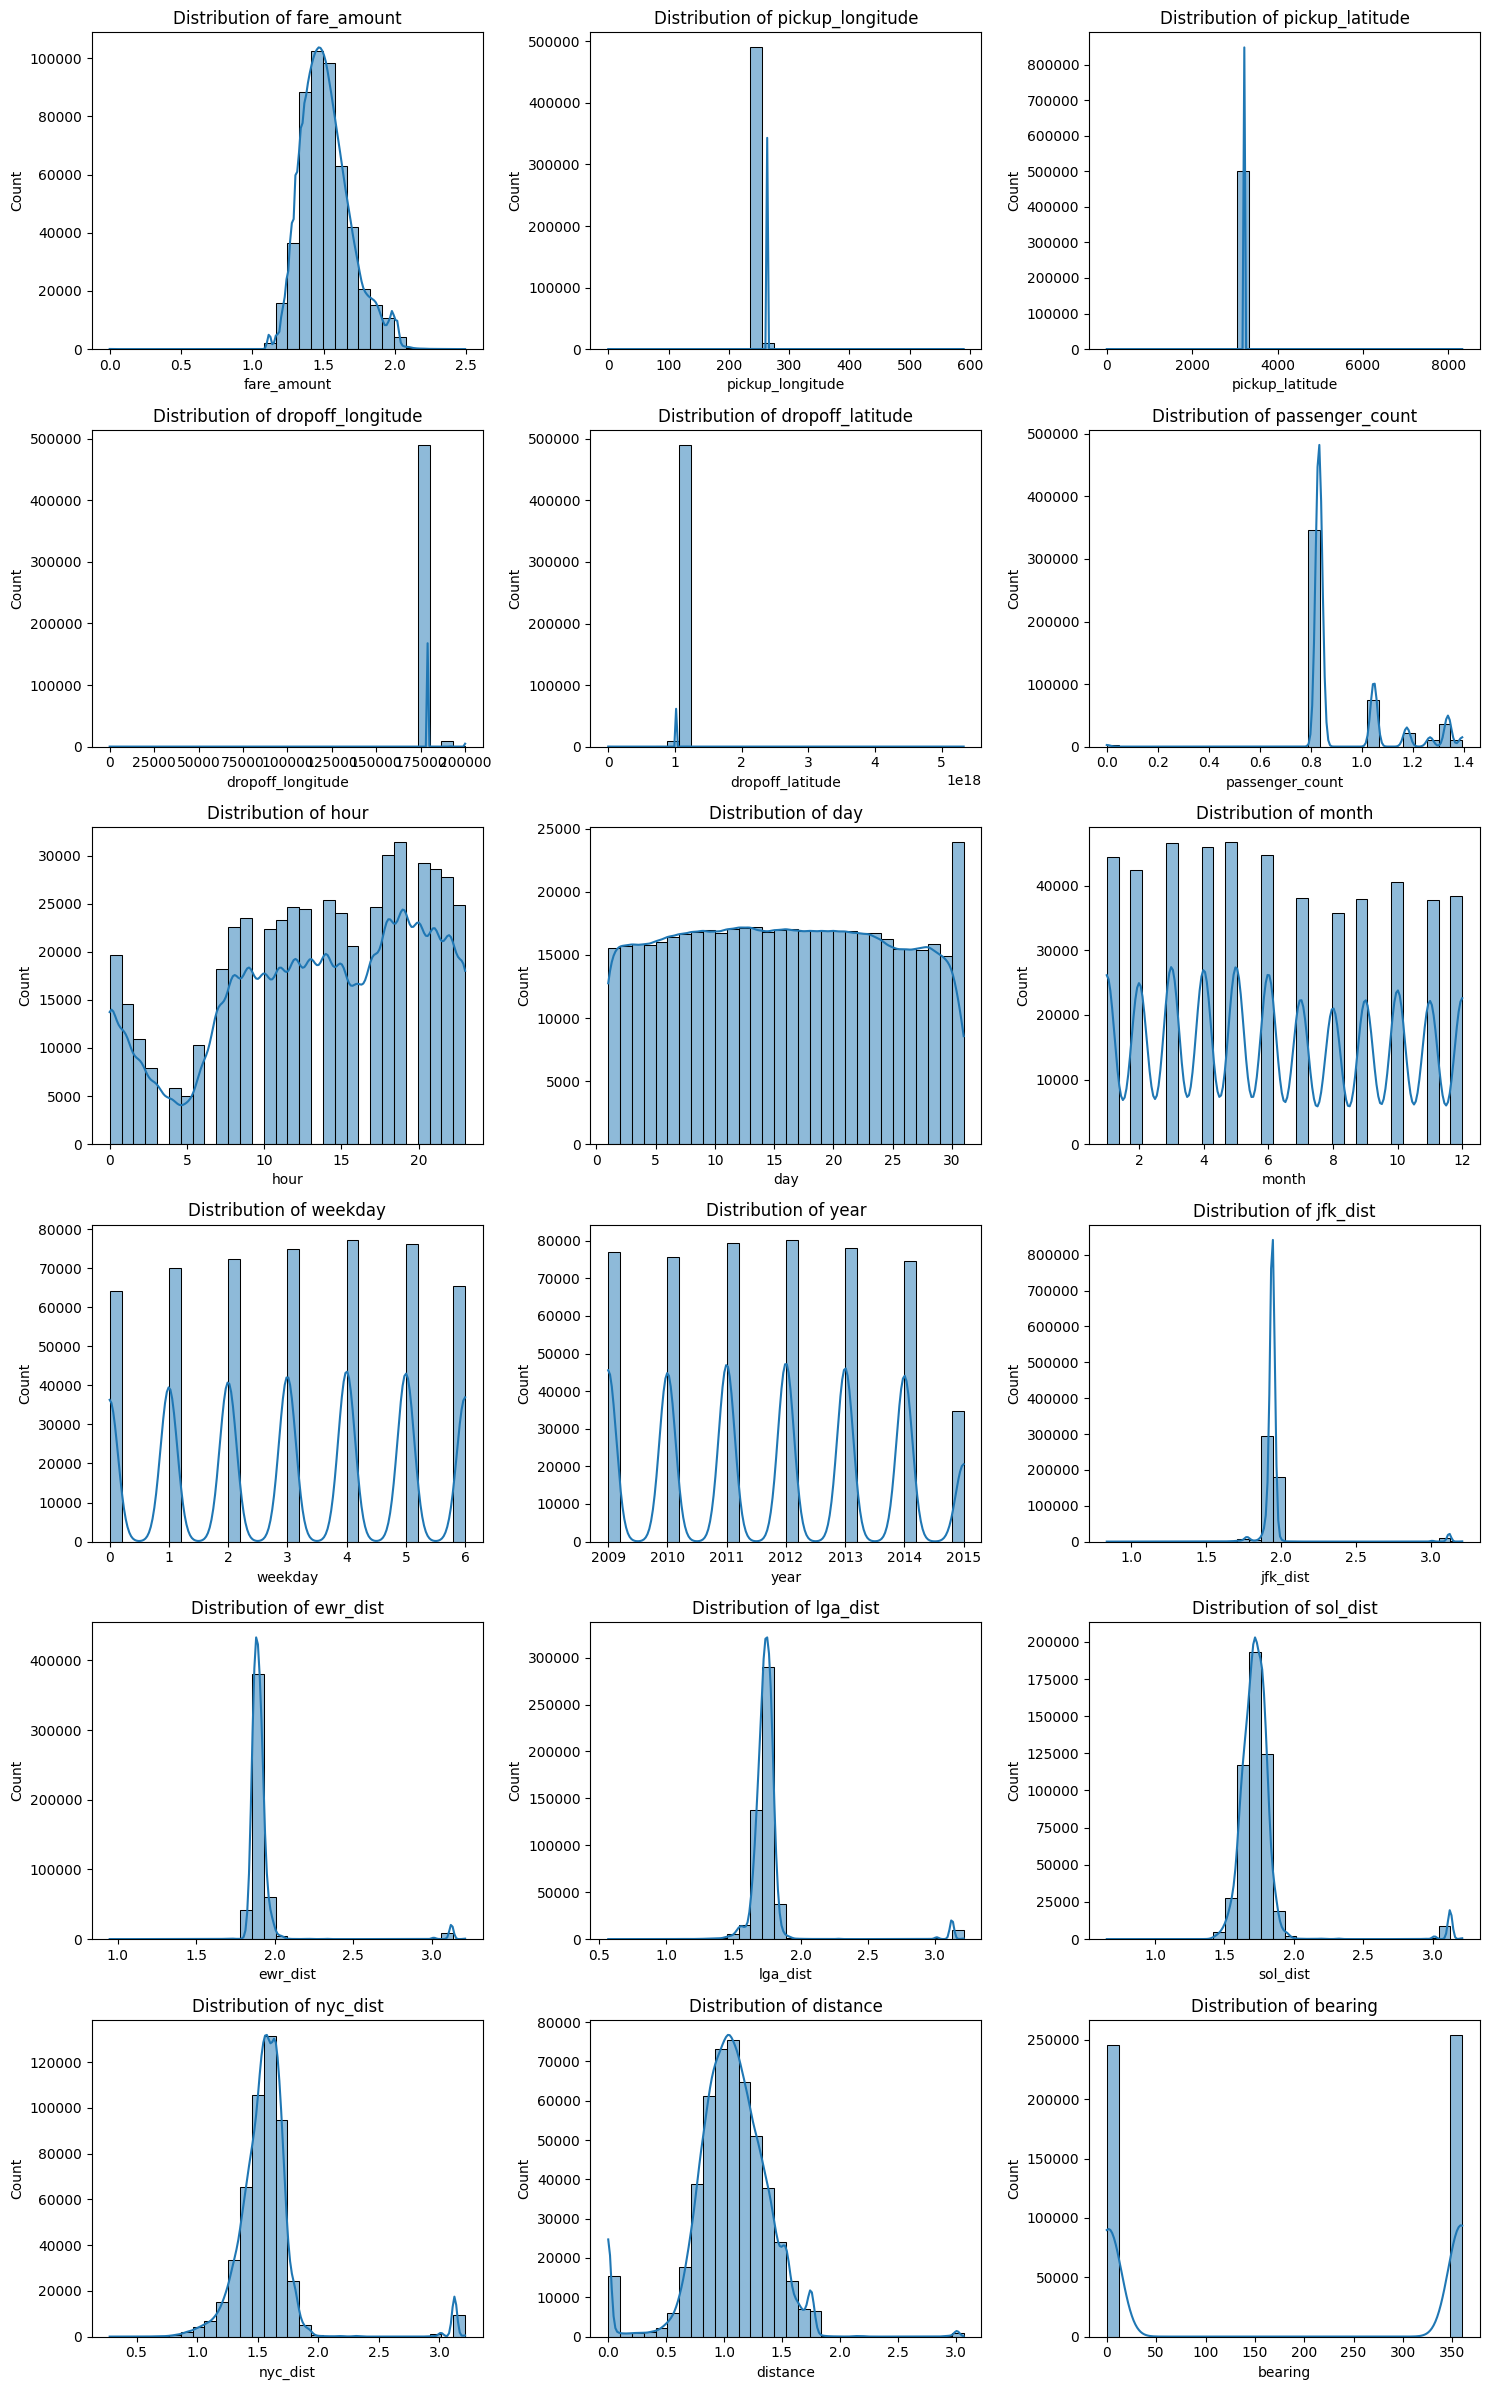

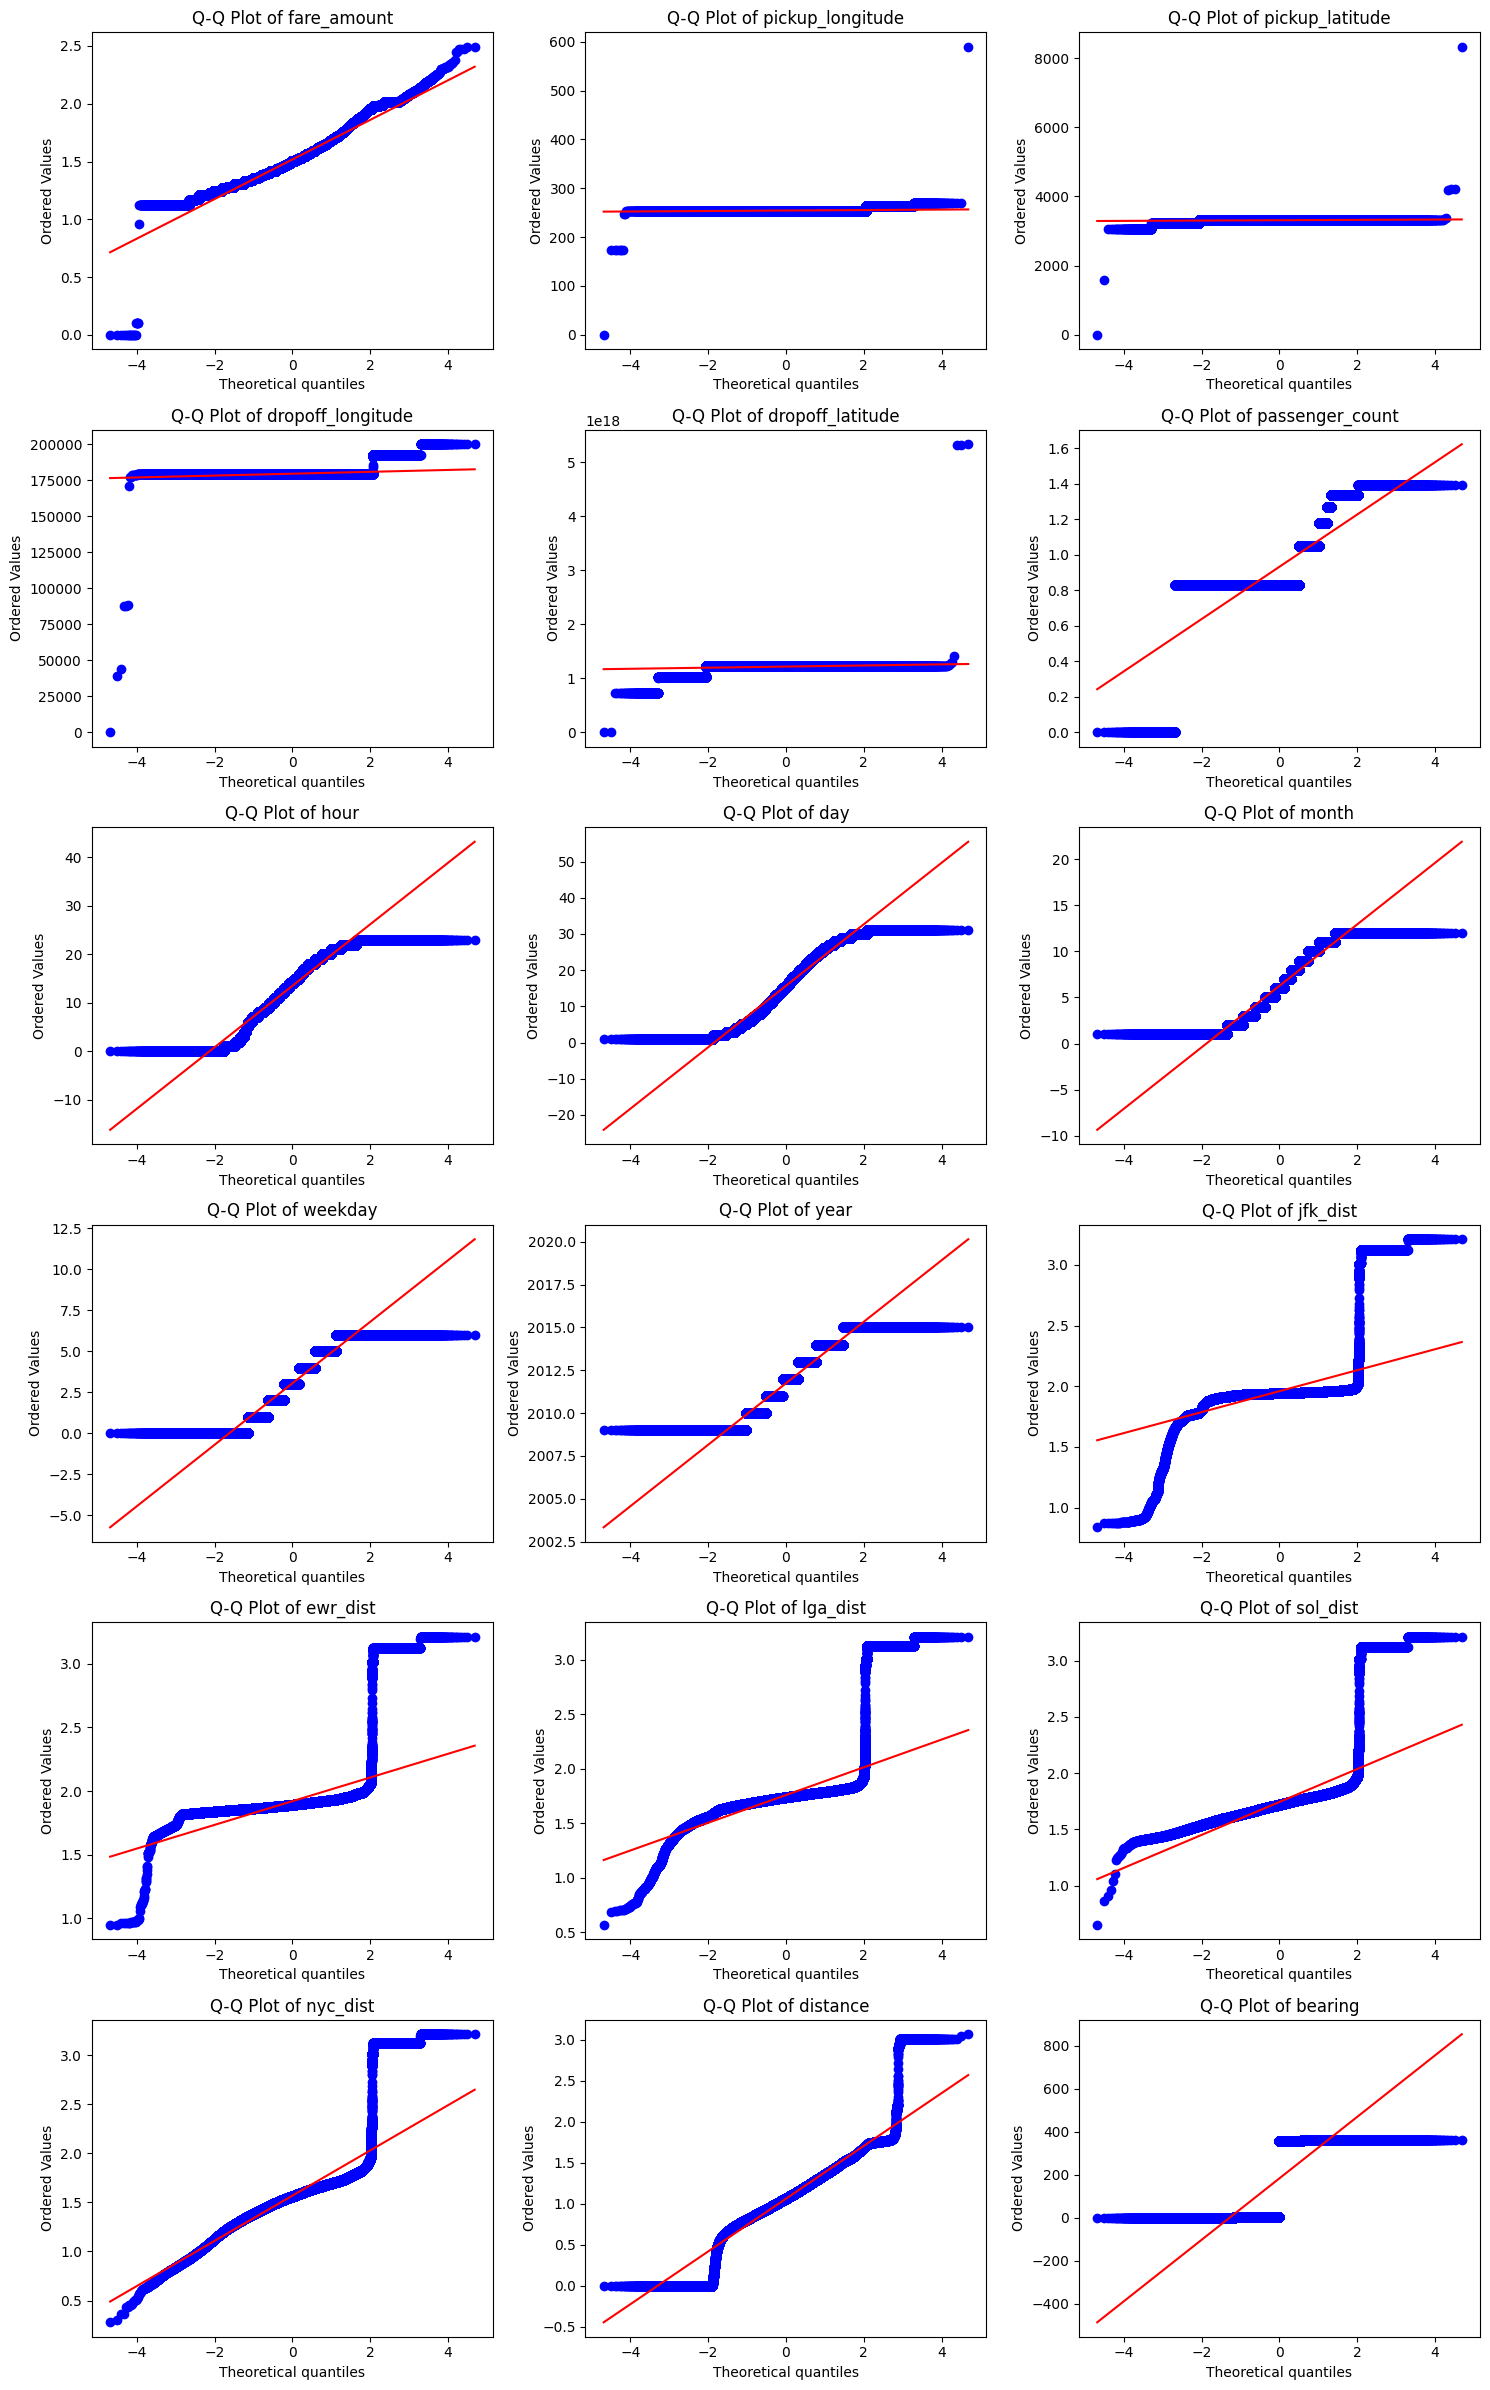

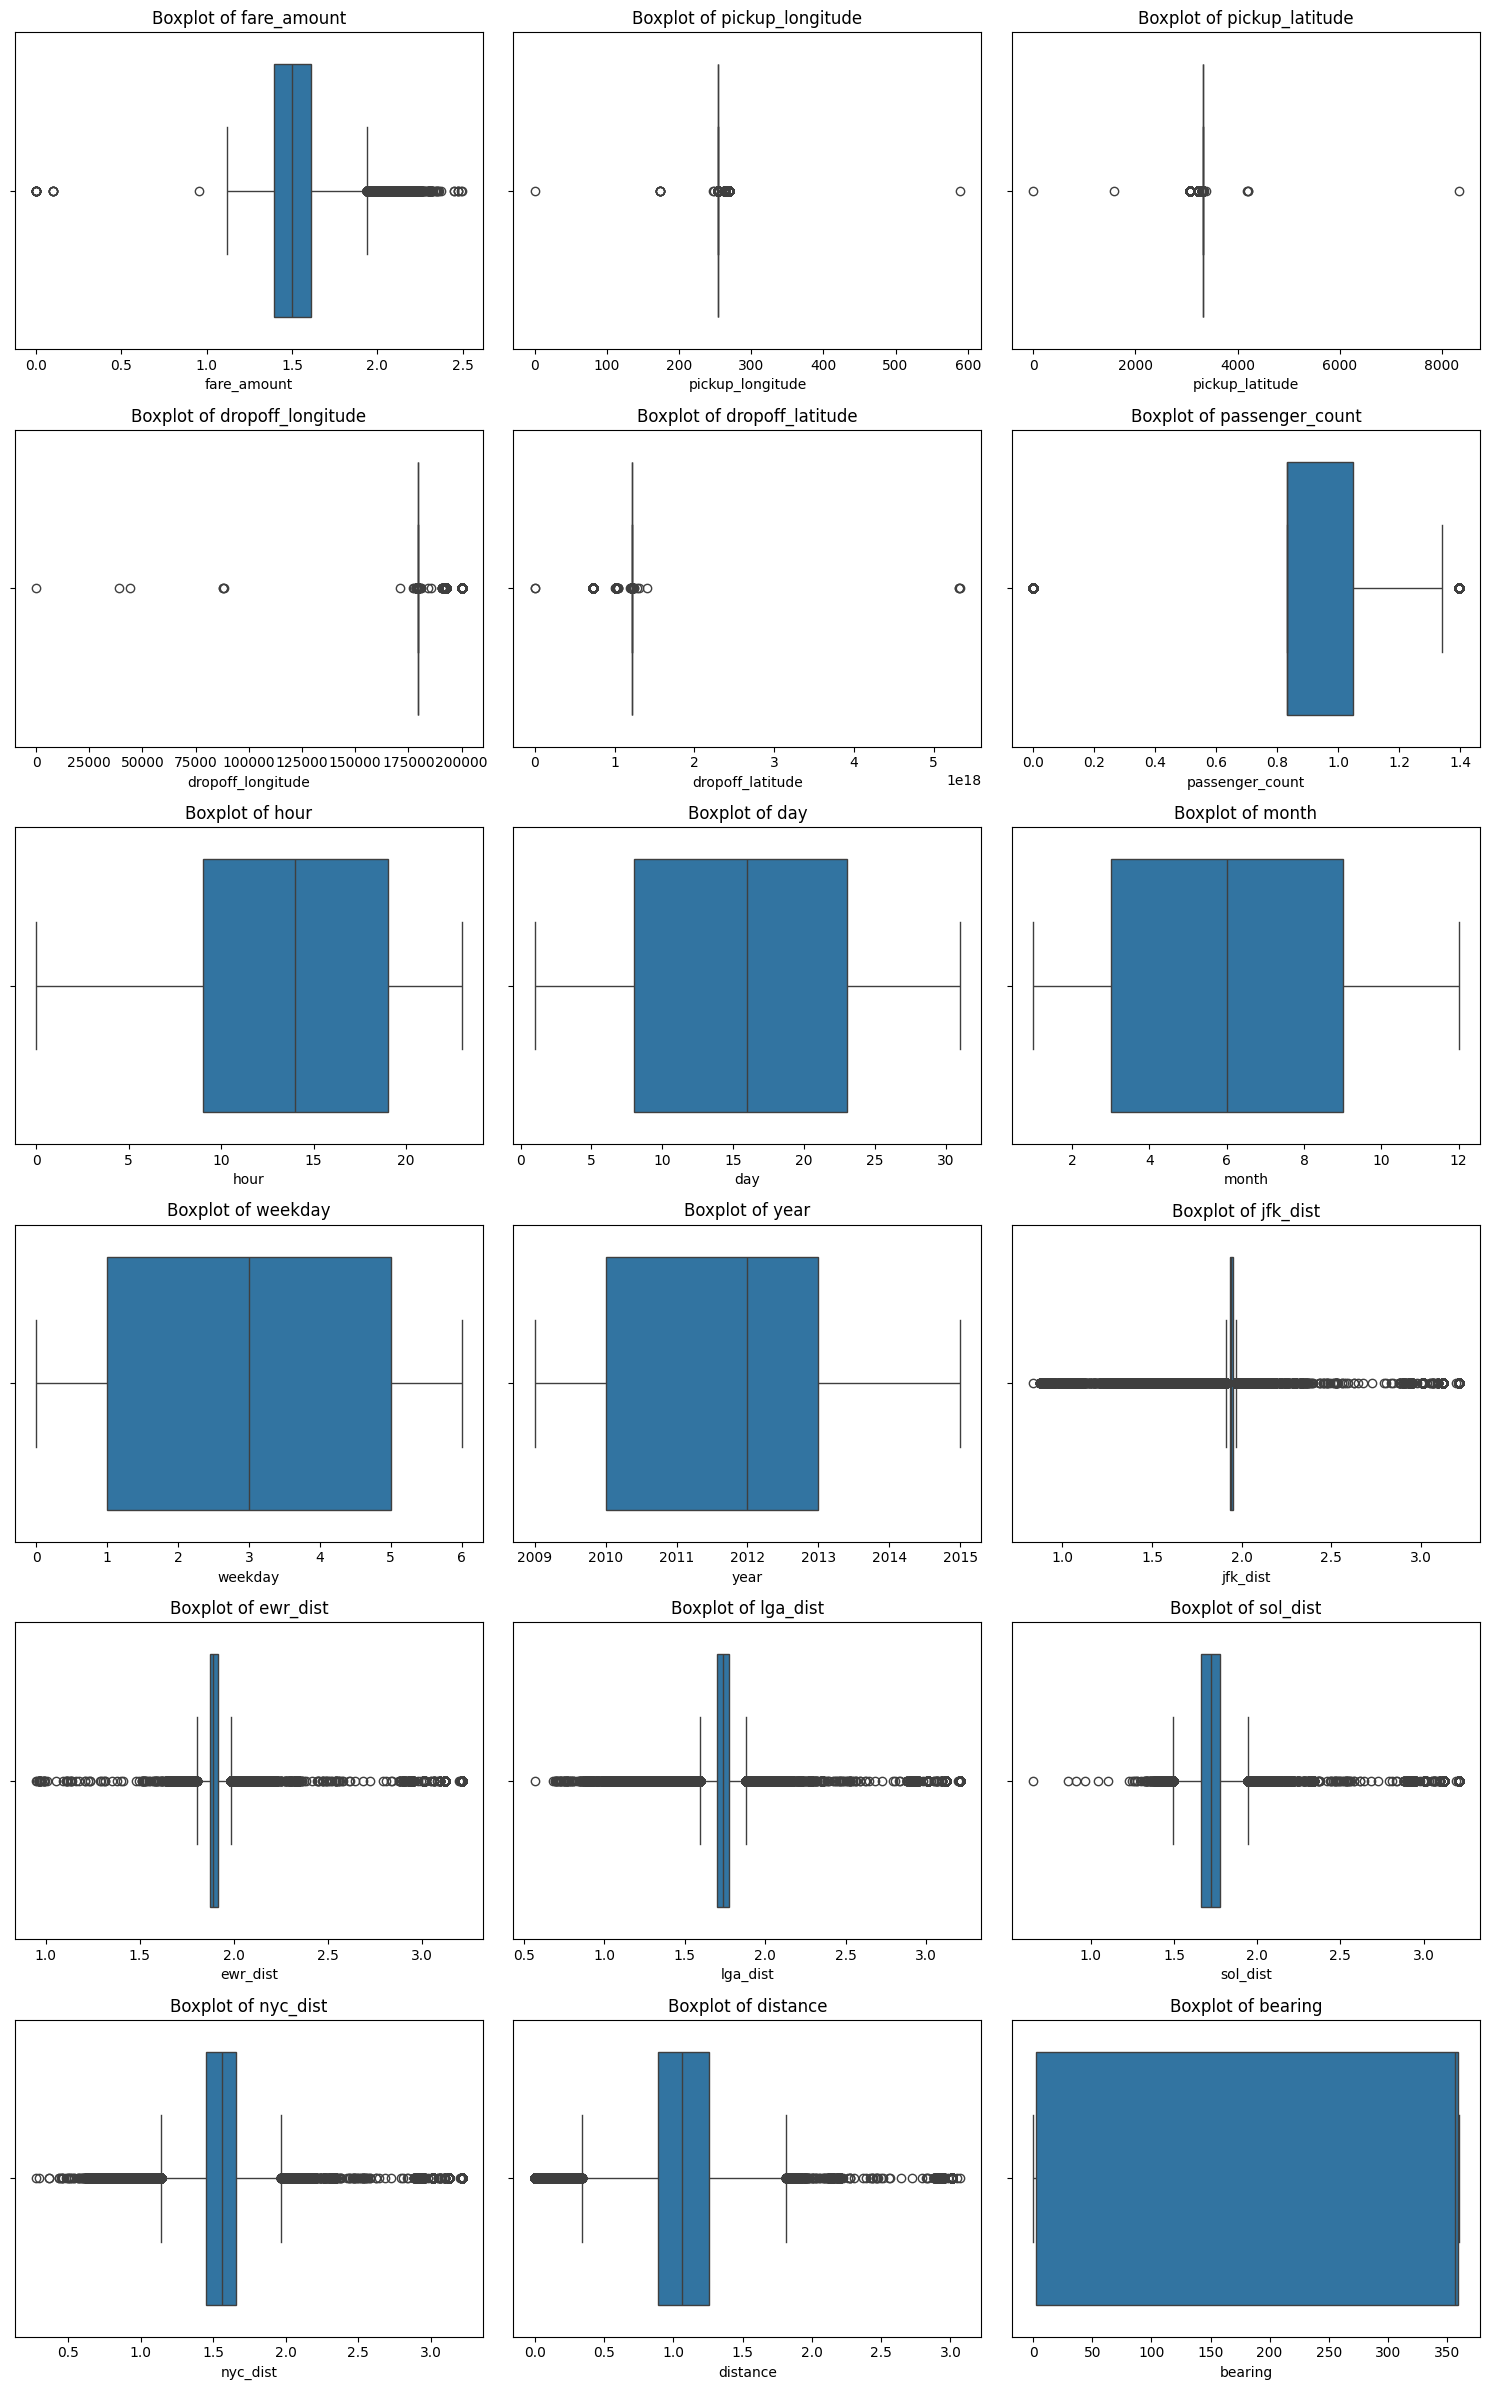

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

num_cols = dataset.select_dtypes(include=['number']).columns  # Get numerical columns
n_cols = 3  # Number of columns in the grid
n_rows = int(np.ceil(len(num_cols) / n_cols))  # Calculate required rows dynamically

plt.figure(figsize=(15, n_rows * 4))

# Histograms
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(dataset[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Q-Q Plots
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    stats.probplot(dataset[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')

plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [42]:
import pandas as pd
from geopy.distance import great_circle

# Load your dataset
df = pd.read_csv(r"e:\Courses\Cellula\Datasets\final_internship_data.csv")  # Update with your actual dataset path

### 1️⃣ Handle Missing Values ###
# Fill missing numerical values with median
numerical_cols = ["fare_amount", "distance", "bearing"]
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Drop rows with missing coordinates
df.dropna(subset=["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"], inplace=True)

### 2️⃣ Create New Features ###
# Haversine Distance (Great Circle Distance)
def haversine_distance(row):
    pickup = (row["pickup_latitude"], row["pickup_longitude"])
    dropoff = (row["dropoff_latitude"], row["dropoff_longitude"])
    return great_circle(pickup, dropoff).kilometers

df["haversine_distance"] = df.apply(haversine_distance, axis=1)

# Manhattan Distance (Sum of absolute lat/lon differences)
df["manhattan_distance"] = (abs(df["dropoff_latitude"] - df["pickup_latitude"]) + 
                            abs(df["dropoff_longitude"] - df["pickup_longitude"]))

# Speed Feature (Trip speed in km/h, assuming fare is proportional to time)
df["speed_kmh"] = df["haversine_distance"] / (df["fare_amount"] / 60)

# Distance from NYC Center
NYC_Center = (40.7128, -74.0060)
def distance_from_nyc(row):
    pickup = (row["pickup_latitude"], row["pickup_longitude"])
    return great_circle(pickup, NYC_Center).kilometers

df["pickup_nyc_distance"] = df.apply(distance_from_nyc, axis=1)

# Time-Based Features
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x in [5, 6] else 0)  # Saturday, Sunday
df["is_rush_hour"] = df["hour"].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)




## 4. Categorical Transformation

### A) Label Encoding

Non-numeric columns remaining: []


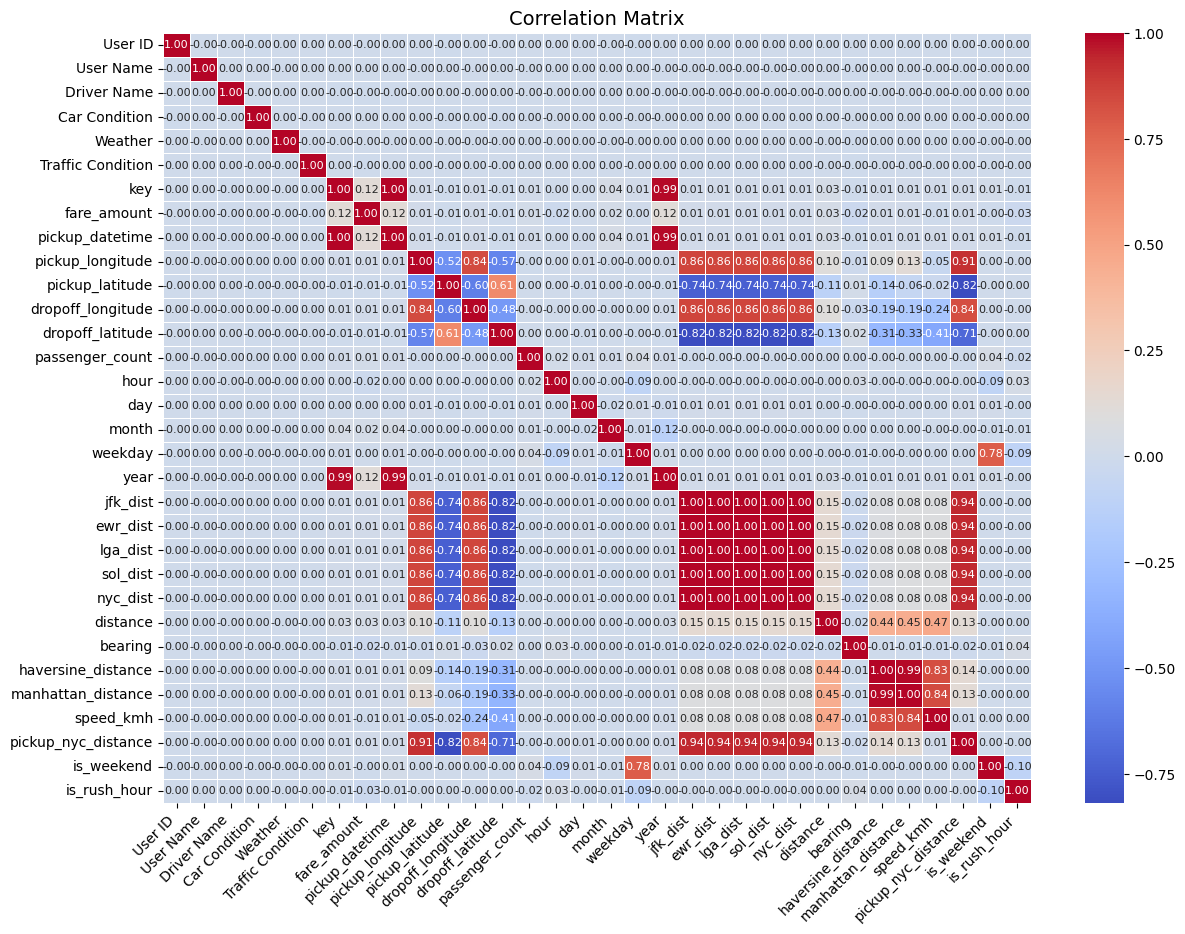

In [45]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Apply Label Encoding to categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Ensure all values are strings before encoding
    label_encoders[col] = le  # Store encoders for inverse transformation if needed

# Check if any columns are still non-numeric
non_numeric_columns = df.select_dtypes(include=['object']).columns
print("Non-numeric columns remaining:", non_numeric_columns.tolist())  # Debugging step

# Compute the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Correlation Matrix", fontsize=14)
plt.show()



In [47]:
import pandas as pd

# Load your dataset
# df = pd.read_csv("your_file.csv")  # Uncomment and modify this if loading from a file

# Compute correlations of all features with the target variable 'fare_amount'
target_correlations = df.corr(numeric_only=True)["fare_amount"].sort_values(ascending=False)

# Display the correlations
print(target_correlations)


fare_amount            1.000000
key                    0.120548
pickup_datetime        0.120537
year                   0.115774
distance               0.026486
month                  0.024429
passenger_count        0.013823
manhattan_distance     0.011293
haversine_distance     0.011006
nyc_dist               0.009764
ewr_dist               0.009654
sol_dist               0.009609
pickup_nyc_distance    0.009595
dropoff_longitude      0.009233
lga_dist               0.009006
pickup_longitude       0.008822
jfk_dist               0.008002
weekday                0.003152
Car Condition          0.002841
day                    0.001900
User Name              0.001708
User ID               -0.000249
Weather               -0.000888
is_weekend            -0.002398
Driver Name           -0.002917
Traffic Condition     -0.003054
pickup_latitude       -0.007779
dropoff_latitude      -0.007865
speed_kmh             -0.008712
hour                  -0.019272
bearing               -0.024303
is_rush_

### B) Model Preparation

##### B.1) Use Mutual Information (MI)

In [48]:

# Define Features 
X = df.drop(columns=["fare_amount"]) 

# Define Target
y = df["fare_amount"]  

In [54]:
# Handle Missing & Infinite Values
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

X = X.replace([np.inf, -np.inf], np.nan)  # Convert inf to NaN
X = X.fillna(X.mean())  # Fill NaNs with mean

# Scale Features (if needed)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Compute Mutual Information for Regression
mi_scores = mutual_info_regression(X, y)  
feature_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Feature Importance (Mutual Information):")
print(feature_scores)

Feature Importance (Mutual Information):
haversine_distance     0.931006
distance               0.909714
manhattan_distance     0.844848
pickup_datetime        0.542069
key                    0.541939
year                   0.469934
speed_kmh              0.240610
jfk_dist               0.197825
ewr_dist               0.163750
nyc_dist               0.144991
lga_dist               0.143627
dropoff_longitude      0.131628
sol_dist               0.121922
dropoff_latitude       0.121539
pickup_longitude       0.108392
pickup_nyc_distance    0.102981
bearing                0.099448
pickup_latitude        0.088912
hour                   0.018543
month                  0.017717
passenger_count        0.007529
weekday                0.003981
is_rush_hour           0.003486
is_weekend             0.001719
Car Condition          0.001171
day                    0.000880
Driver Name            0.000849
User Name              0.000304
Weather                0.000000
Traffic Condition      0.000000

## 5.Train Test Split

### 5.1) Selected Features

In [56]:
# Define independent variables (selected features)
X = df[[
    "haversine_distance", "distance", "manhattan_distance", 
    "pickup_datetime", "year", "speed_kmh",
    "jfk_dist", "ewr_dist", "nyc_dist", "lga_dist",
    "dropoff_longitude", "dropoff_latitude", "pickup_longitude", "sol_dist"
]]

# Define dependent variable (target)
y = df["fare_amount"]


### 5.2) Preperations before Modeling

In [61]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# Step 1: Split the dataset (without stratify for regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Handle NaN & Infinite Values
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Step 3: Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

# Step 4: Handle Multicollinearity using PCA
pca = PCA(n_components=0.95)  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 5: Generate Synthetic Data Using KNN
def generate_synthetic_samples(X, y, num_samples=500):
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X, y)
    
    # Generate random noise based on existing data distribution
    noise = np.random.normal(scale=0.1, size=(num_samples, X.shape[1]))  
    
    # Select random indices
    indices = np.random.randint(0, X.shape[0], size=num_samples)
    
    # Generate synthetic X values
    X_synthetic = X[indices] + noise
    y_synthetic = knn.predict(X_synthetic)  # Predict y values
    
    return np.vstack([X, X_synthetic]), np.hstack([y, y_synthetic])

# Apply data augmentation
X_train_resampled, y_train_resampled = generate_synthetic_samples(X_train_pca, y_train)


## 6. Modeling & Accuracy

### A) KNN

In [66]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=15)

# Train the model
knn_reg.fit(X_train_resampled, y_train_resampled)  # Continuous target

# Predict the continuous values
y_pred = knn_reg.predict(X_test_pca)

# Evaluate using Regression Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-Squared (R²): {r2_score(y_test, y_pred):.4f}")


from sklearn.model_selection import cross_val_score

# Use 5-fold cross-validation
cv_scores = cross_val_score(knn_reg, X_train_resampled, y_train_resampled, 
                            cv=5, scoring='r2')  # Using R² instead of accuracy

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")


Mean Absolute Error (MAE): 10.94
Mean Squared Error (MSE): 214.57
R-Squared (R²): -1.1649
Cross-Validation R² Scores: [0.56887858 0.57130103 0.56890713 0.56969444 0.53557846]
Mean R²: 0.5629
Standard Deviation: 0.0137


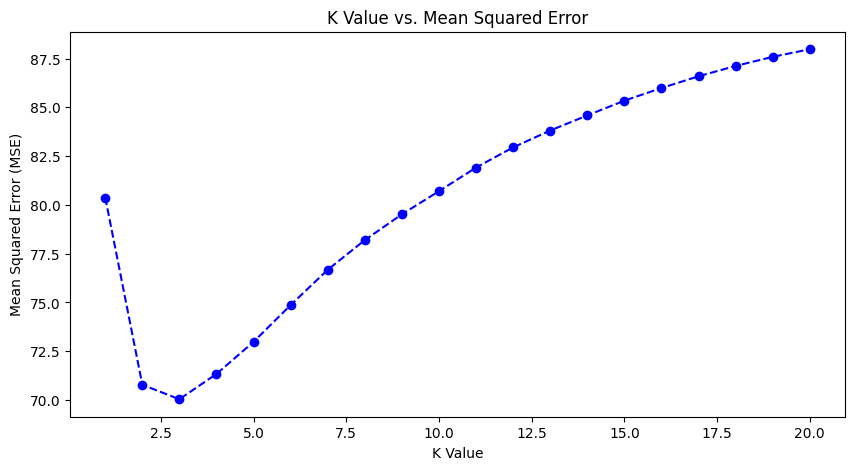

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

mse_values = []  # Store Mean Squared Errors

for k in range(1, 21):  # Tune K value
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    mse_values.append(mean_squared_error(y_test, y_pred_k))  # Store MSE

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), mse_values, marker='o', linestyle='dashed', color='b')
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("K Value vs. Mean Squared Error")
plt.show()


### B) Linear Regression

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Make predictions
y_pred = lin_reg.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression - MSE: {mse:.4f}, R²: {r2:.4f}")
from sklearn.model_selection import cross_val_score

# Use 5-fold cross-validation
cv_scores = cross_val_score(lin_reg, X_train_resampled, y_train_resampled, 
                            cv=5, scoring='r2')  # Using R² instead of accuracy

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")


Linear Regression - MSE: 64.2776, R²: 0.3515
Cross-Validation R² Scores: [ 0.0114474   0.00052004  0.01042361  0.01208688 -0.06691389]
Mean R²: -0.0065
Standard Deviation: 0.0305


### C) Decesion Tree

In [70]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the model
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train, y_train)

# Make predictions
y_pred = dt_reg.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree - MSE: {mse:.4f}, R²: {r2:.4f}")

from sklearn.model_selection import cross_val_score

# Use 5-fold cross-validation
cv_scores = cross_val_score(dt_reg, X_train_resampled, y_train_resampled, 
                            cv=5, scoring='r2')  # Using R² instead of accuracy

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")


Decision Tree - MSE: 19.8543, R²: 0.7997
Cross-Validation R² Scores: [0.37887069 0.38442982 0.38630315 0.38476051 0.31249234]
Mean R²: 0.3694
Standard Deviation: 0.0286
